# Italian Financial Challenge - Starter Template

**Student Name:** Talaat Madi, Karol Cardillo, Michele Elia, Diego Diaz

**Challenge:** Revenue Forecasting

**Date:** [Date]

## 1. Problem Statement and Objectives (TO UPDATE)

**Challenge:** We have choosed Revenue Forecarsting for the challenge it gives and also as it seems the most instresting of the three proposed challenge

**Objective:** Predict `revenue_change`

**Success Criteria:** [Define what "good" performance looks like for your chosen challenge]

**Approach:** [Briefly outline your planned approach]

In [16]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Loading and Exploration

Load the training data and perform initial exploration.

In [17]:
# Load training data
train_df = pd.read_csv('../data/processed/train_data.csv')

print(f"Dataset shape: {train_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")
print(f"\nFirst few rows:")
train_df.head()

Dataset shape: (11828, 30)

Columns: ['company_id', 'fiscal_year', 'province', 'region', 'ateco_sector', 'legal_form', 'years_in_business', 'total_fixed_assets', 'current_assets', 'total_assets', 'shareholders_equity', 'total_debt', 'short_term_debt', 'long_term_debt', 'production_value', 'production_costs', 'operating_income', 'financial_income', 'financial_expenses', 'net_profit_loss', 'roe', 'roi', 'leverage', 'current_ratio', 'quick_ratio', 'debt_to_assets', 'profit_margin', 'bankruptcy_next_year', 'financial_health_class', 'revenue_change']

First few rows:


,company_id,fiscal_year,province,region,ateco_sector,legal_form,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,bankruptcy_next_year,financial_health_class,revenue_change
0,COMP_00000,2018,NaN,Campania,47,SRL,32,2.422343e+08,9.504819e+08,1.192716e+09,3.728702e+08,8.198459e+08,5.601842e+08,2.596617e+08,1.846636e+09,1.611363e+09,2.352729e+08,4886785.12,20068071.29,2.152049e+08,0.5772,0.1973,2.1987,1.6967,1.0180,0.6874,0.1165,0,B,NaN
1,COMP_00000,2019,NaN,Campania,47,SRL,33,3.983639e+07,1.411226e+08,1.809589e+08,5.700701e+07,1.239519e+08,7.135345e+07,5.259848e+07,4.289159e+08,3.896038e+08,3.931218e+07,58246.06,2537224.20,3.677495e+07,0.6451,0.2172,2.1743,1.9778,1.1867,0.6850,0.0857,0,B,-76.77
2,COMP_00000,2020,NaN,Campania,47,SRL,34,6.662250e+08,1.367208e+09,2.033433e+09,3.029046e+08,1.730529e+09,9.904004e+08,7.401282e+08,6.956197e+09,6.988489e+09,-3.229208e+07,5327332.51,55844558.38,-8.813664e+07,-0.2910,-0.0159,5.7131,1.3805,0.8283,0.8510,-0.0127,0,D,1521.81
3,COMP_00000,2021,NaN,Campania,47,SRL,35,4.637187e+07,2.524228e+08,2.987947e+08,3.901098e+07,2.597837e+08,1.527674e+08,1.070163e+08,5.031839e+08,5.047235e+08,-1.539645e+06,116335.80,7828741.61,-9.368387e+06,-0.2401,-0.0052,6.6592,1.6523,0.9914,0.8694,-0.0186,0,D,-92.77
4,COMP_00001,2018,CA,Sardegna,62,SRL,8,8.348035e+07,1.325697e+08,2.160500e+08,6.566937e+07,1.503807e+08,7.582482e+07,7.455584e+07,4.113380e+08,3.912414e+08,2.009667e+07,640538.94,5860639.22,1.423603e+07,0.2168,0.0930,2.2900,1.7484,1.0490,0.6960,0.0346,0,B,NaN


In [18]:
# Basic information
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11828 entries, 0 to 11827
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              11828 non-null  str    
 1   fiscal_year             11828 non-null  int64  
 2   province                10909 non-null  str    
 3   region                  11828 non-null  str    
 4   ateco_sector            11828 non-null  int64  
 5   legal_form              11828 non-null  str    
 6   years_in_business       11828 non-null  int64  
 7   total_fixed_assets      11828 non-null  float64
 8   current_assets          11828 non-null  float64
 9   total_assets            11828 non-null  float64
 10  shareholders_equity     11828 non-null  float64
 11  total_debt              11828 non-null  float64
 12  short_term_debt         11828 non-null  float64
 13  long_term_debt          11828 non-null  float64
 14  production_value        11828 non-null  float64
 

In [19]:
# Summary statistics
train_df.describe()

,fiscal_year,ateco_sector,years_in_business,total_fixed_assets,current_assets,total_assets,shareholders_equity,total_debt,short_term_debt,long_term_debt,production_value,production_costs,operating_income,financial_income,financial_expenses,net_profit_loss,roe,roi,leverage,current_ratio,quick_ratio,debt_to_assets,profit_margin,bankruptcy_next_year,revenue_change
count,11828.000000,11828.000000,11828.000000,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,1.182800e+04,11783.000000,11828.000000,11783.000000,11828.000000,11828.000000,11828.000000,11828.000000,11828.000000,8829.000000
mean,2019.495350,45.827697,35.179405,1.029206e+09,1.438435e+09,2.467641e+09,9.163141e+08,1.551327e+09,8.534656e+08,6.978617e+08,3.969063e+09,3.680129e+09,2.889337e+08,6.418314e+06,5.464980e+07,2.342839e+08,0.254267,0.123253,2.135329,1.869953,1.121972,0.633231,0.058008,0.007102,453.434570
std,1.116482,16.677183,19.908095,6.120958e+09,6.873106e+09,1.248305e+10,5.023564e+09,7.724478e+09,4.360360e+09,3.493369e+09,1.896096e+10,1.757911e+10,1.574126e+09,3.930832e+07,2.850800e+08,1.348222e+09,0.577374,0.091036,2.159040,0.614015,0.368409,0.114868,0.039245,0.083976,4601.920625
min,2018.000000,10.000000,0.000000,1.267167e+06,1.278800e+06,2.545968e+06,-3.330561e+09,1.839791e+06,8.985461e+05,9.412449e+05,2.329670e+06,1.580518e+06,-2.688184e+09,6.241000e+01,5.926949e+04,-4.062689e+09,-39.177100,-0.475300,0.818200,0.551000,0.330600,0.450000,-0.149700,0.000000,-99.940000
25%,2018.000000,41.000000,18.000000,7.319803e+07,1.244471e+08,2.087793e+08,7.070428e+07,1.294646e+08,6.925617e+07,5.666362e+07,2.984883e+08,2.731290e+08,1.698626e+07,3.569547e+05,4.355200e+06,1.049173e+07,0.110350,0.061900,1.165650,1.430800,0.858500,0.538500,0.030500,0.000000,-68.590000
50%,2019.000000,46.000000,35.000000,1.905995e+08,3.125597e+08,5.212379e+08,1.815958e+08,3.264152e+08,1.744802e+08,1.462585e+08,8.040019e+08,7.459428e+08,5.128590e+07,1.068330e+06,1.110262e+07,3.798727e+07,0.221600,0.105000,1.680300,1.811750,1.087050,0.627500,0.060300,0.000000,3.040000
75%,2020.000000,56.000000,52.000000,5.398741e+08,8.387197e+08,1.394478e+09,5.022747e+08,8.795087e+08,4.777298e+08,3.960070e+08,2.241163e+09,2.075266e+09,1.538062e+08,3.178533e+06,3.005698e+07,1.226862e+08,0.390750,0.170900,2.484850,2.238925,1.343325,0.713800,0.090000,0.000000,238.850000
max,2021.000000,82.000000,71.000000,2.548712e+11,2.512549e+11,5.061262e+11,1.956145e+11,3.105116e+11,1.699685e+11,1.405431e+11,6.044366e+11,5.736470e+11,5.621927e+10,1.640114e+09,9.311030e+09,5.011818e+10,1.771600,0.490600,101.153800,4.539300,2.723600,1.192300,0.120000,1.000000,302126.480000


In [20]:
# Check for missing values
missing_values = train_df.isnull().sum()
missing_pct = (missing_values / len(train_df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values:")
print(missing_df)

Missing Values:
                Missing Count  Percentage
revenue_change           2999   25.355090
province                  919    7.769699
roe                        45    0.380453
leverage                   45    0.380453


In [21]:
print("\nRevenue Change Statistics:")
print(train_df['revenue_change'].describe())
print(f"\nMissing revenue_change: {train_df['revenue_change'].isnull().sum()}")


Revenue Change Statistics:
count      8829.000000
mean        453.434570
std        4601.920625
min         -99.940000
25%         -68.590000
50%           3.040000
75%         238.850000
max      302126.480000
Name: revenue_change, dtype: float64

Missing revenue_change: 2999


### Exploratory Data Analysis (EDA)

Create visualizations to understand the data better.

#### Distribution plots for key financial 

Observation: 
- Ratios show a distribution which is not symmetric
- Outliers are not rare
- Standardization needed for futher processing

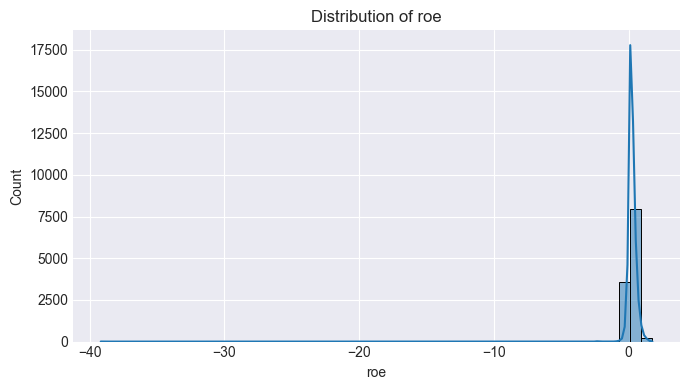

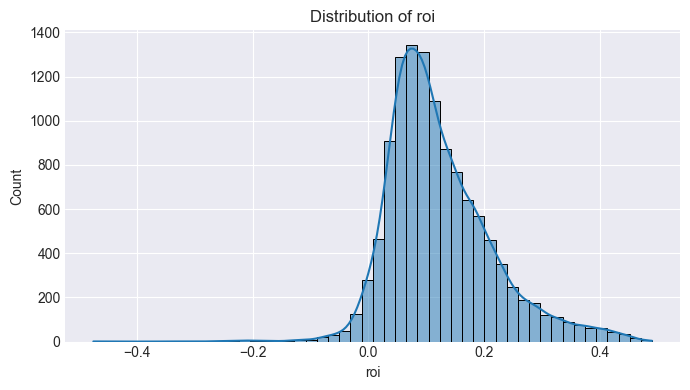

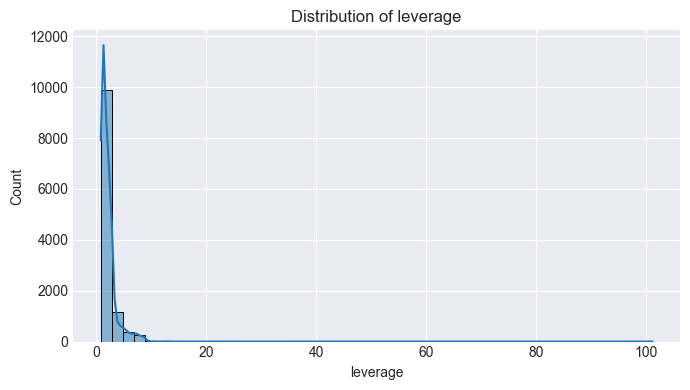

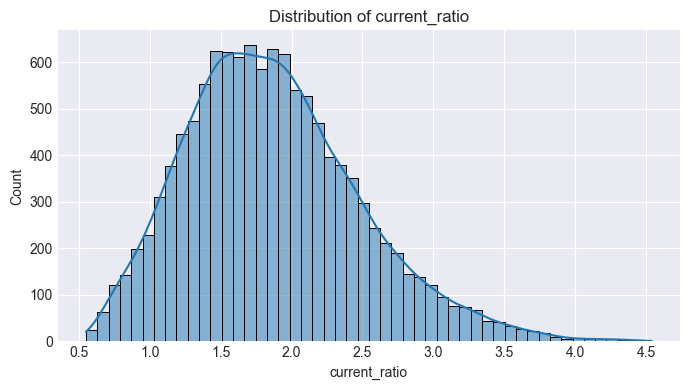

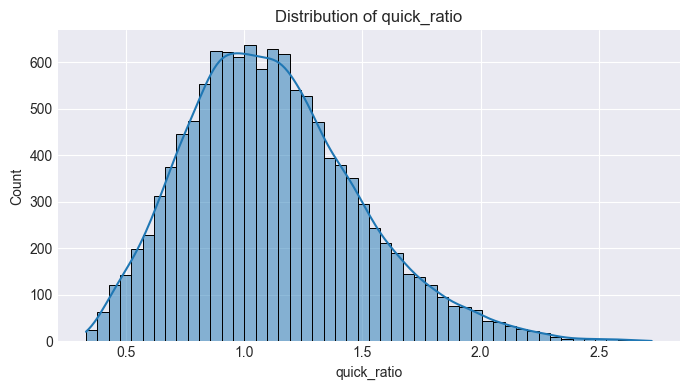

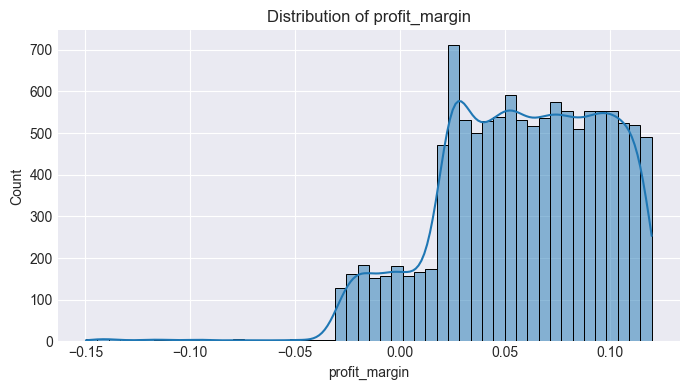

In [22]:
output = "../Images/DistributionsPlots"
os.makedirs(output, exist_ok=True)

financial_ratios = ["roe", "roi", "leverage", "current_ratio", "quick_ratio", "dept_to_assets", "profit_margin"]

financial_ratios = [c for c in financial_ratios if c in train_df.columns]

for col in financial_ratios:
    plt.figure(figsize=(7, 4))
    sns.histplot(train_df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()

    filepath = os.path.join(output, f"{col}_distribution.png")
    plt.savefig(filepath)

    plt.show()
    plt.close() 

#### Correlation heatmap

Observation:
- Strong correlations appear among size-related variables
- Some profitability metrics show correlation with revenue change
- Multicollinearity motivates the use of regularized models

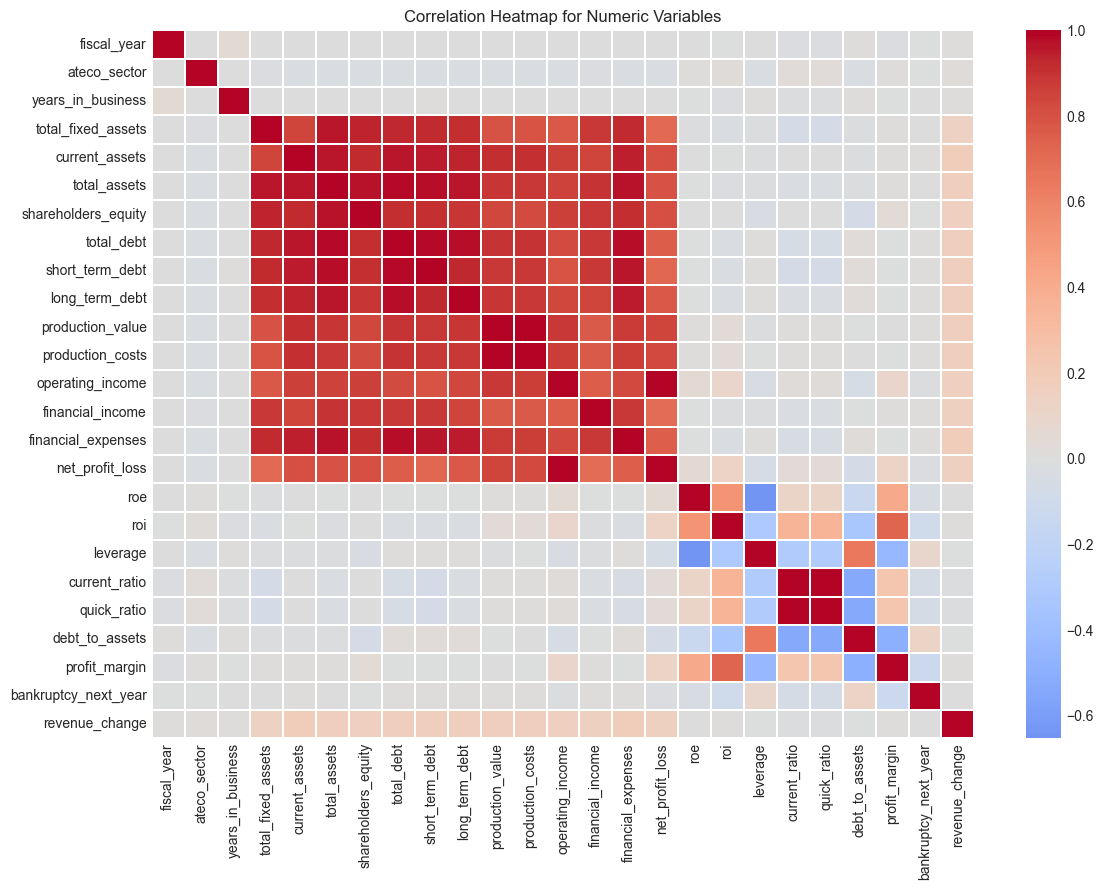

In [23]:
numeric = train_df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 9))
corr = numeric.corr()

sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)

plt.title("Correlation Heatmap for Numeric Variables")
plt.tight_layout()
plt.savefig(os.path.join("../Images", "correlation_heatmap.png"))
plt.show()
plt.close()

#### Target Variable by Sector, Region, and Year

Observation:
- Revenue growth varies across sectors and regions
- Temporal patterns suggest macroeconomic effects
- Time-aware validation is necessary

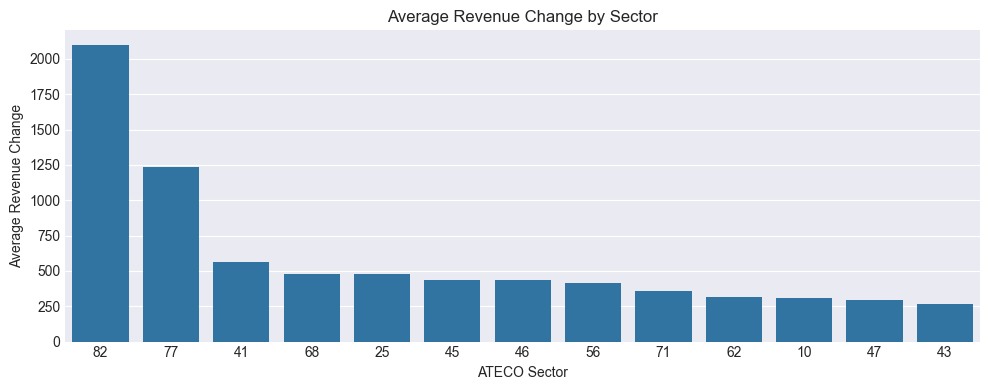

In [24]:
# Sector
os.makedirs("../Images/TargetVariable", exist_ok=True)

plt.figure(figsize=(10, 4))
mean = (train_df.groupby("ateco_sector")["revenue_change"].mean().sort_values(ascending=False))

sns.barplot(x=mean.index.astype(str), y = mean.values)

plt.title("Average Revenue Change by Sector")
plt.xlabel("ATECO Sector")
plt.ylabel("Average Revenue Change")
plt.tight_layout()
plt.savefig(os.path.join("../Images/TargetVariable", "revenue_change_by_sector.png"))
plt.show()
plt.close()


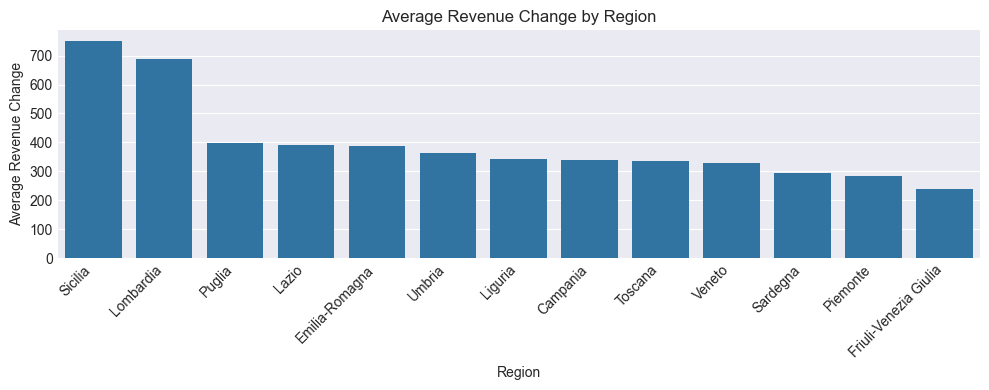

In [25]:
# Region

plt.figure(figsize=(10, 4))
mean = (train_df.groupby("region")["revenue_change"].mean().sort_values(ascending=False))
sns.barplot(x=mean.index.astype(str), y = mean.values)
plt.title("Average Revenue Change by Region")
plt.xlabel("Region")
plt.ylabel("Average Revenue Change")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join("../Images/TargetVariable", "revenue_change_by_region.png"))
plt.show()
plt.close()

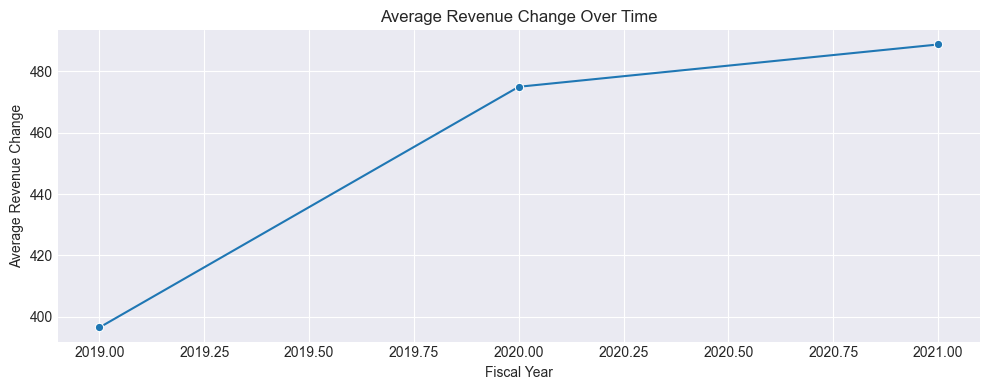

In [26]:
# Fiscal Year

plt.figure(figsize=(10, 4))
mean = (train_df.groupby("fiscal_year")["revenue_change"].mean().sort_values(ascending=False))
sns.lineplot(x=mean.index, y = mean.values, marker="o")
plt.title("Average Revenue Change Over Time")
plt.xlabel("Fiscal Year")
plt.ylabel("Average Revenue Change")
plt.tight_layout()
plt.savefig(os.path.join("../Images/TargetVariable", "revenue_change_by_fiscal_year.png"))
plt.show()
plt.close()


#### Box Plots

Observation:
- Outliers are frequent in financial data
- Justifies robust metrics (MAE) and regularization
- Outliers should be handled carefully, not blindly removed

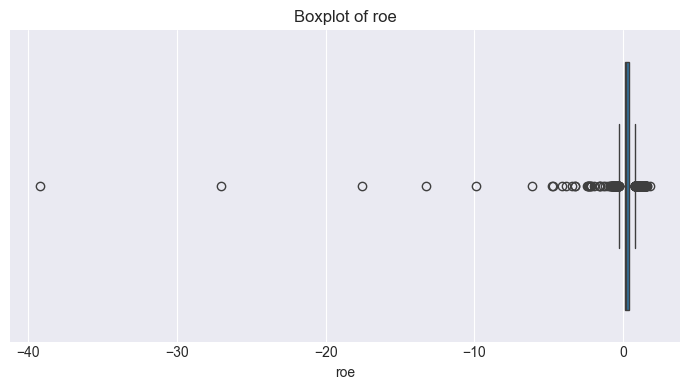

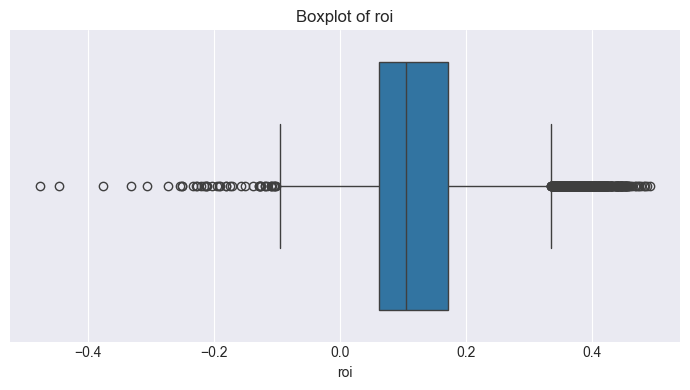

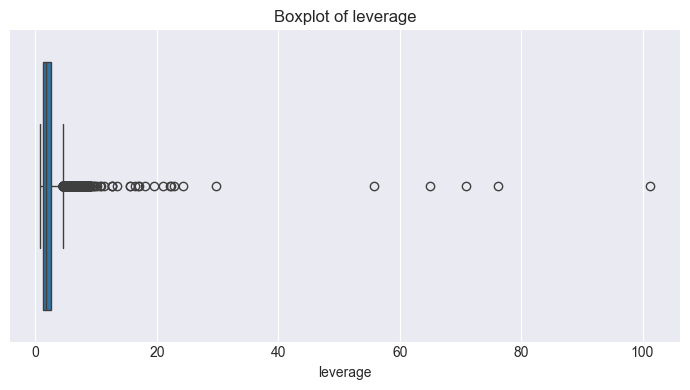

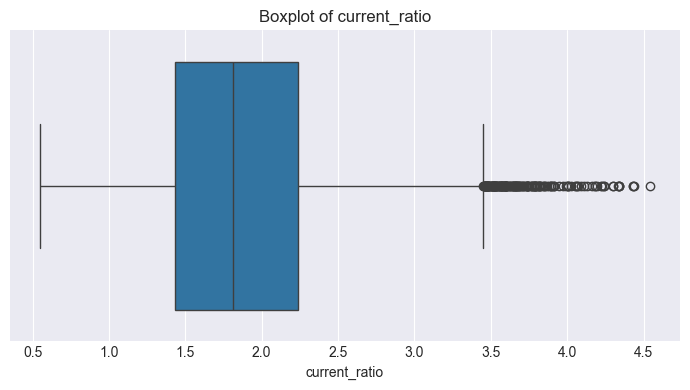

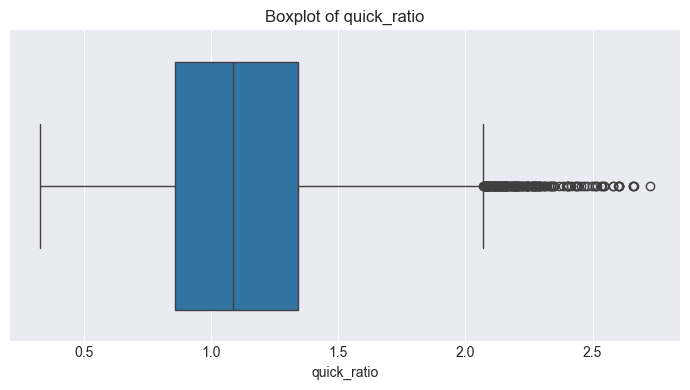

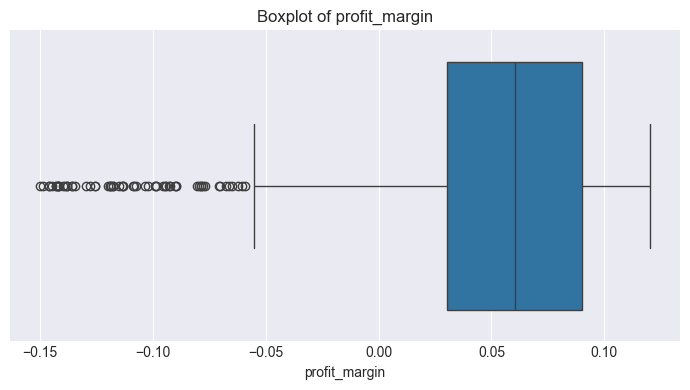

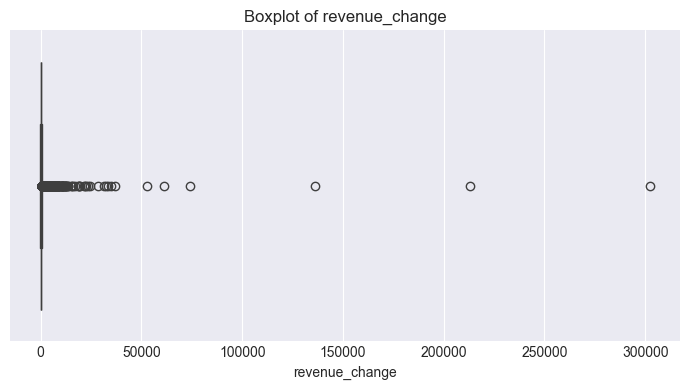

In [27]:
os.makedirs("../Images/Boxplots", exist_ok=True)

for col in financial_ratios + ['revenue_change']:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=train_df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.savefig(os.path.join("../Images/Boxplots", f"{col}_boxplot.png"))
    plt.show()
    plt.close()

In [32]:
pd.options.display.float_format = '{:,.2f}'.format

summary = pd.DataFrame({
    "dtype": train_df.dtypes,
    "missing_values": train_df.isnull().sum(),
    "missing_%": train_df.isnull().mean()*100,
    "unique_values": train_df.nunique()
})

# statistiche solo per colonne numeriche
summary["min"] = train_df.min(numeric_only=True)
summary["max"] = train_df.max(numeric_only=True)
summary["mean"] = train_df.mean(numeric_only=True)
summary["median"] = train_df.median(numeric_only=True)

summary = summary.sort_values("missing_%", ascending=False)

summary

,dtype,missing_values,missing_%,unique_values,min,max,mean,median
revenue_change,float64,2999,25.36,7734,-99.94,"302,126.48",453.43,3.04
province,str,919,7.77,19,NaN,NaN,NaN,NaN
leverage,float64,45,0.38,9428,0.82,101.15,2.14,1.68
roe,float64,45,0.38,6342,-39.18,1.77,0.25,0.22
operating_income,float64,0,0.00,11828,"-2,688,184,167.70","56,219,268,014.67","288,933,661.47","51,285,903.07"
financial_health_class,str,0,0.00,4,NaN,NaN,NaN,NaN
bankruptcy_next_year,int64,0,0.00,2,0.00,1.00,0.01,0.00
profit_margin,float64,0,0.00,1556,-0.15,0.12,0.06,0.06
debt_to_assets,float64,0,0.00,3882,0.45,1.19,0.63,0.63
quick_ratio,float64,0,0.00,7870,0.33,2.72,1.12,1.09


Identifiers and Temporal Variables

Check company_id format

Number of invalid company IDs: 0
All company IDs start with 'COMP_'

Years per company (sample):
company_id
COMP_00000    4
COMP_00001    4
COMP_00002    4
COMP_00003    3
COMP_00004    4
Name: fiscal_year, dtype: int64

Distribution of companies by number of years:
fiscal_year
1      20
2      24
3      60
4    2895
Name: count, dtype: int64
Companies with 1 year(s) of data: 20
Companies with 2 year(s) of data: 24
Companies with 3 year(s) of data: 60
Companies with 4 year(s) of data: 2895


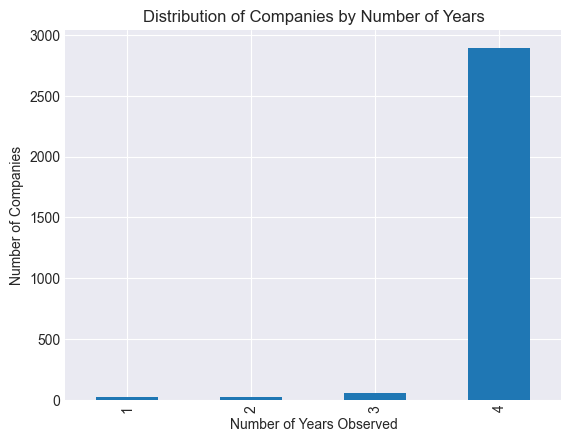

In [ ]:

invalid_ids = train_df[~train_df["company_id"].str.startswith("COMP_")]

print("Number of invalid company IDs:", len(invalid_ids))

if len(invalid_ids) > 0:
    print(invalid_ids["company_id"].head())
else:
    print("All company IDs start with 'COMP_'")


years_per_company = train_df.groupby("company_id")["fiscal_year"].nunique()

print("\nYears per company (sample):")
print(years_per_company.head())


distribution = years_per_company.value_counts().sort_index()

print("\nDistribution of companies by number of years:")
print(distribution)



for years, count in distribution.items():
    print(f"Companies with {years} year(s) of data: {count}")



import matplotlib.pyplot as plt

distribution.plot(kind="bar")

plt.title("Distribution of Companies by Number of Years")
plt.xlabel("Number of Years Observed")
plt.ylabel("Number of Companies")

plt.show()

Company Characteristics

ateco sector

In [99]:

train_df["ateco_sector"] = train_df["ateco_sector"].astype(str)
train_df["ateco_2digit"] = train_df["ateco_sector"].str[:2]
ateco_map = {
    "01-03": "Agriculture, Forestry, Fishing",
    "05-09": "Mining and Quarrying",
    "10-33": "Manufacturing",
    "35": "Electricity, Gas, Steam",
    "36-39": "Water Supply, Sewerage, Waste",
    "41-43": "Construction",
    "45-47": "Wholesale and Retail Trade",
    "49-53": "Transportation and Storage",
    "55-56": "Accommodation and Food Service",
    "58-63": "Information and Communication",
    "64-66": "Financial and Insurance Activities",
    "68": "Real Estate Activities",
    "69-75": "Professional, Scientific, Technical Activities",
    "77-82": "Administrative and Support Services",
    "84": "Public Administration",
    "85": "Education",
    "86-88": "Human Health and Social Work",
    "90-93": "Arts, Entertainment, Recreation",
    "94-96": "Other Service Activities"
}
def map_sector(code):
    code = int(code)

    for k in ateco_map:
        if "-" in k:
            start, end = k.split("-")
            if int(start) <= code <= int(end):
                return ateco_map[k]
        else:
            if code == int(k):
                return ateco_map[k]

    return "Other"
train_df["sector_category"] = train_df["ateco_2digit"].apply(map_sector)
sector_dist = train_df.groupby("sector_category")["company_id"].nunique().sort_values(ascending=False)

print(sector_dist)
ateco_per_company = (
    train_df.groupby("company_id")["ateco_sector"]
    .nunique()
)

print("Companies that change ATECO sector:", (ateco_per_company > 1).sum())

sector_category
Wholesale and Retail Trade                        980
Construction                                      672
Manufacturing                                     519
Information and Communication                     239
Accommodation and Food Service                    190
Administrative and Support Services               151
Professional, Scientific, Technical Activities    138
Real Estate Activities                            110
Name: company_id, dtype: int64
Companies that change ATECO sector: 0


REGION

In [38]:
print("Unique regions:")
print(train_df["region"].unique())

print("Number of regions:", train_df["region"].nunique())

region_dist = train_df.groupby("region")["company_id"].nunique().sort_values(ascending=False)

print(region_dist)

Unique regions:
<StringArray>
[             'Campania',              'Sardegna',                'Puglia',
        'Emilia-Romagna',             'Lombardia',                 'Lazio',
               'Sicilia',                'Veneto',              'Piemonte',
               'Toscana',                'Umbria', 'Friuli-Venezia Giulia',
               'Liguria']
Length: 13, dtype: str
Number of regions: 13
region
Lombardia                636
Lazio                    479
Emilia-Romagna           355
Veneto                   297
Campania                 232
Sicilia                  227
Piemonte                 201
Toscana                  183
Puglia                   122
Liguria                  101
Sardegna                  63
Umbria                    53
Friuli-Venezia Giulia     50
Name: company_id, dtype: int64


LEGAL FORM

In [39]:
print("Unique legal forms:")
print(train_df["legal_form"].unique())
legal_form_dist = train_df.groupby("legal_form")["company_id"].nunique().sort_values(ascending=False)

print(legal_form_dist)


Unique legal forms:
<StringArray>
['SRL', 'SAS', 'SNC', 'SPA', 'SAPA']
Length: 5, dtype: str
legal_form
SRL     2170
SPA      400
SAS      228
SNC      155
SAPA      46
Name: company_id, dtype: int64


In [ ]:
PROVINCE

In [ ]:

missing_rows = train_df["province"].isna().sum()

print("Missing province values (rows):", missing_rows)

companies_with_missing = train_df.loc[
    train_df["province"].isna(), "company_id"
].nunique()

print("Companies with at least one missing province:", companies_with_missing)

companies_no_province = (
    train_df.groupby("company_id")["province"]
    .apply(lambda x: x.isna().all())
)

companies_no_province = companies_no_province.sum()

print("Companies with NO province in any year:", companies_no_province)

companies_computable = companies_with_missing - companies_no_province

print("Companies where province can be imputed:", companies_computable)

print("Companies remaining without province:", companies_no_province)

Missing province values (rows): 919
Companies with at least one missing province: 232
Companies with NO province in any year: 232
Companies where province can be imputed: 0
Companies remaining without province: 232


In [48]:
province_region_dist = (
    train_df.dropna(subset=["province"])
    .groupby(["region", "province"])["company_id"]
    .nunique()
    .reset_index(name="unique_companies")
    .sort_values(["region", "unique_companies"], ascending=[True, False])
)

province_region_dist

,region,province,unique_companies
0,Emilia-Romagna,BO,167
1,Emilia-Romagna,MO,78
3,Emilia-Romagna,RE,59
2,Emilia-Romagna,PR,51
4,Friuli-Venezia Giulia,TS,50
5,Lazio,RM,479
6,Liguria,GE,101
8,Lombardia,MI,573
7,Lombardia,BG,63
9,Piemonte,TO,201


In [53]:
companies_missing_province = train_df[train_df["province"].isna()]

region_dist_missing_province = (
    companies_missing_province
    .groupby("region")["company_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(region_dist_missing_province)

region
Campania    232
Name: company_id, dtype: int64


In [ ]:
for region, count in region_dist_missing_province.items():
    print(f"{region}: {count} companies without province")
    

Campania: 232 companies without province


In [100]:
train_df.loc[
    train_df["province"].isna() & (train_df["region"] == "Campania"),
    "province"
] = "Campania_Unknown"

In [101]:
print("Remaining missing provinces:", train_df["province"].isna().sum())

Remaining missing provinces: 0


In [ ]:

missing_yib_rows = train_df["years_in_business"].isna().sum()
print("Missing years_in_business (rows):", missing_yib_rows)

missing_yib_companies = train_df.loc[
    train_df["years_in_business"].isna(), "company_id"
].nunique()
print("Unique companies with missing years_in_business:", missing_yib_companies)


yib_distribution = (
    train_df.dropna(subset=["years_in_business"])
    .groupby("years_in_business")["company_id"]
    .nunique()
    .sort_index()
)

print("\nDistribution of unique companies by years_in_business:")
print(yib_distribution)

Missing years_in_business (rows): 0
Unique companies with missing years_in_business: 0

Distribution of unique companies by years_in_business:
years_in_business
0      77
1     121
2     157
3     166
4     174
5     167
6     170
7     173
8     153
9     162
10    161
11    156
12    176
13    168
14    174
15    164
16    160
17    159
18    162
19    179
20    167
21    185
22    185
23    170
24    189
25    182
26    171
27    169
28    157
29    150
30    167
31    179
32    184
33    188
34    172
35    172
36    164
37    157
38    162
39    157
40    166
41    177
42    185
43    186
44    182
45    182
46    175
47    162
48    176
49    174
50    175
51    185
52    178
53    176
54    182
55    186
56    191
57    179
58    157
59    153
60    152
61    160
62    175
63    174
64    168
65    159
66    167
67    164
68    156
69    118
70     71
71     31
Name: company_id, dtype: int64


Balance Sheet Variables

 assets

TOTAL ASSETS = current assets + fixed assets 

In [106]:
tolerance = 0.1

asset_diff = train_df["total_assets"] - (
    train_df["total_fixed_assets"] + train_df["current_assets"]
)

inconsistent_assets = train_df[abs(asset_diff) > tolerance]

print("Rows where asset identity fails:", len(inconsistent_assets))
print(
    "Percentage inconsistent:",
    len(inconsistent_assets) / len(train_df) * 100
)

Rows where asset identity fails: 0
Percentage inconsistent: 0.0


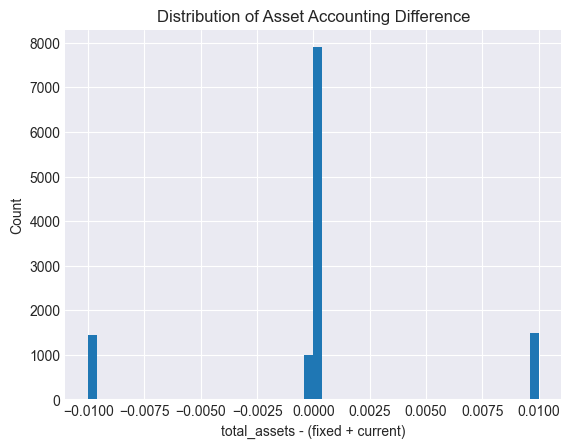

In [103]:
import matplotlib.pyplot as plt

plt.hist(asset_diff.dropna(), bins=50)

plt.title("Distribution of Asset Accounting Difference")
plt.xlabel("total_assets - (fixed + current)")
plt.ylabel("Count")

plt.show()

here i see if it is allright

we calculate wether a ertain company as a tottal assets og a higher of tot percent and if it all right we keep it if not we don t put the mean between the year assed and year next asssets but we just erase them

In [112]:
train_df = train_df.sort_values(["company_id", "fiscal_year"])

train_df["asset_ratio"] = (
    train_df.groupby("company_id")["total_assets"]
    .transform(lambda x: x / x.shift(1))
)

In [113]:
max_growth = train_df["asset_ratio"].max()
min_ratio = train_df["asset_ratio"].min()

print("Maximum growth ratio:", max_growth)
print("Maximum decline ratio:", min_ratio)

Maximum growth ratio: 1091.6654211860384
Maximum decline ratio: 0.0010631726686598259


In [114]:
train_df.loc[
    train_df["asset_ratio"] == max_growth,
    ["company_id", "fiscal_year", "total_assets", "asset_ratio"]
]

,company_id,fiscal_year,total_assets,asset_ratio
9793,COMP_02485,2021,"56,800,286,428.16","1,091.67"


In [115]:
train_df.loc[
    train_df["asset_ratio"] == min_ratio,
    ["company_id", "fiscal_year", "total_assets", "asset_ratio"]
]

,company_id,fiscal_year,total_assets,asset_ratio
11472,COMP_02910,2021,"222,379,813.81",0.00


In [116]:
train_df["asset_pct_change"] = (
    train_df.groupby("company_id")["total_assets"]
    .pct_change()
)

print("Max % increase:", train_df["asset_pct_change"].max())
print("Max % decline:", train_df["asset_pct_change"].min())

Max % increase: 1090.6654211860384
Max % decline: -0.9989368273313401


fixed assets

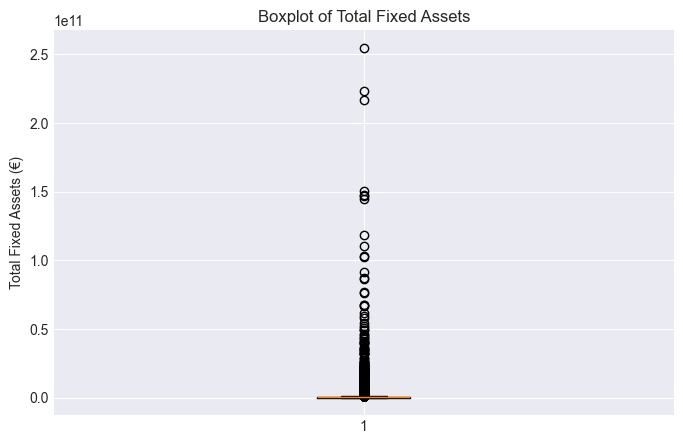

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(train_df["total_fixed_assets"].dropna())

plt.title("Boxplot of Total Fixed Assets")
plt.ylabel("Total Fixed Assets (€)")

plt.show()

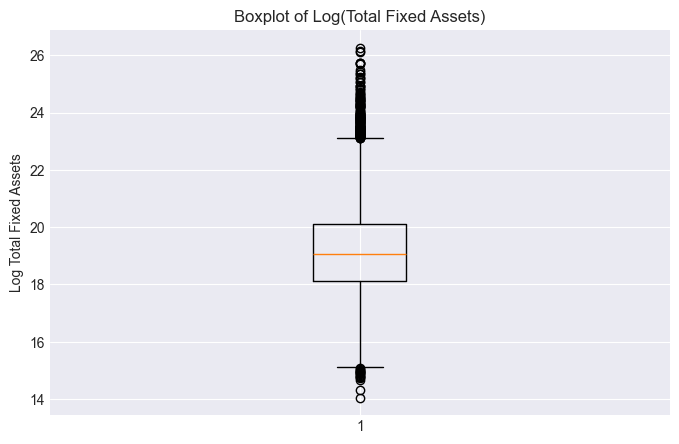

In [109]:
import numpy as np

plt.figure(figsize=(8,5))

plt.boxplot(np.log1p(train_df["total_fixed_assets"].dropna()))

plt.title("Boxplot of Log(Total Fixed Assets)")
plt.ylabel("Log Total Fixed Assets")

plt.show()

In [117]:
print("Min fixed assets:", train_df["total_fixed_assets"].min())
print("Max fixed assets:", train_df["total_fixed_assets"].max())
print("Mean fixed assets:", train_df["total_fixed_assets"].mean())
print("Median fixed assets:", train_df["total_fixed_assets"].median())

Min fixed assets: 1267167.28
Max fixed assets: 254871222410.09
Mean fixed assets: 1029206034.6968709
Median fixed assets: 190599471.635


In [118]:
train_df["total_fixed_assets"].describe()

count            11,828.00
mean      1,029,206,034.70
std       6,120,958,154.91
min           1,267,167.28
25%          73,198,030.24
50%         190,599,471.63
75%         539,874,121.35
max     254,871,222,410.09
Name: total_fixed_assets, dtype: float64

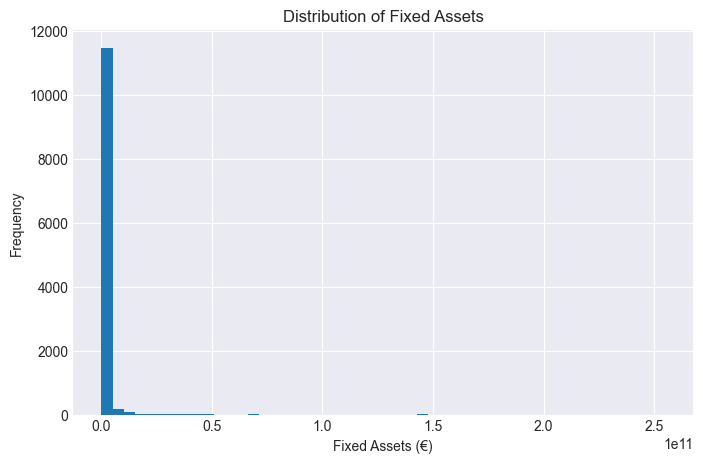

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(train_df["total_fixed_assets"].dropna(), bins=50)

plt.title("Distribution of Fixed Assets")
plt.xlabel("Fixed Assets (€)")
plt.ylabel("Frequency")

plt.show()

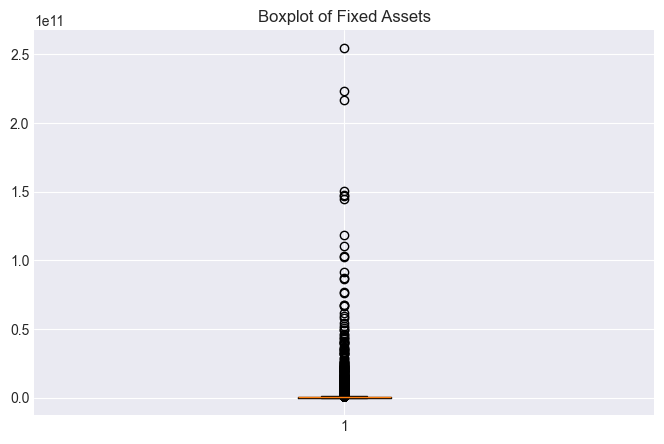

In [120]:
plt.figure(figsize=(8,5))

plt.boxplot(train_df["total_fixed_assets"].dropna())

plt.title("Boxplot of Fixed Assets")

plt.show()

In [121]:
train_df = train_df.sort_values(["company_id","fiscal_year"])

train_df["fixed_asset_ratio"] = (
    train_df.groupby("company_id")["total_fixed_assets"]
    .transform(lambda x: x / x.shift(1))
)

In [122]:
print("Max growth fixed assets:", train_df["fixed_asset_ratio"].max())
print("Max decline fixed assets:", train_df["fixed_asset_ratio"].min())

Max growth fixed assets: 1253.7827047117155
Max decline fixed assets: 0.0009047640879257215


In [123]:
extreme_fixed = train_df[
    (train_df["fixed_asset_ratio"] > 50) |
    (train_df["fixed_asset_ratio"] < 0.02)
]

print("Extreme fixed asset jumps:", len(extreme_fixed))

Extreme fixed asset jumps: 215


In [124]:
bad_companies_fixed = extreme_fixed["company_id"].unique()

print("Companies with abnormal fixed asset jumps:", len(bad_companies_fixed))

Companies with abnormal fixed asset jumps: 187


In [129]:
p99 = train_df["total_fixed_assets"].quantile(0.99)

print("99th percentile:", p99)


99th percentile: 13598122409.928785


In [130]:
train_df_p99 = train_df[
    train_df["total_fixed_assets"] <= p99
]

Min: 1278800.5
Max: 251254933402.31
Mean: 1438435231.5058818
Median: 312559707.395


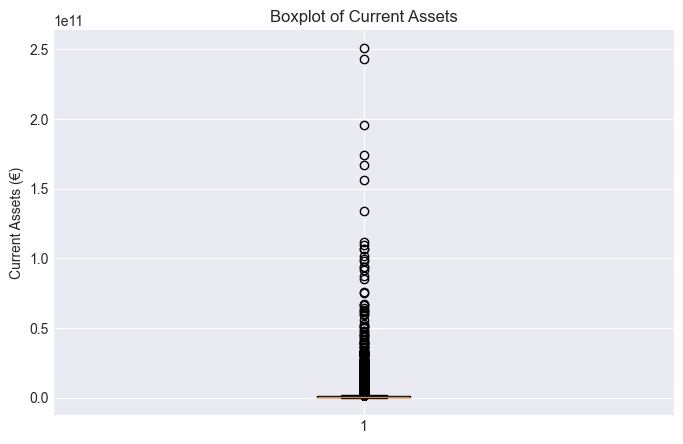

In [131]:
train_df_p99 = train_df[
    train_df["total_fixed_assets"] <= p99
]


print("Min:", train_df["current_assets"].min())
print("Max:", train_df["current_assets"].max())
print("Mean:", train_df["current_assets"].mean())
print("Median:", train_df["current_assets"].median())
train_df["current_assets"].describe()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(train_df["current_assets"].dropna())

plt.title("Boxplot of Current Assets")
plt.ylabel("Current Assets (€)")

plt.show()

In [132]:
print("Rows before:", len(train_df))
print("Rows after:", len(train_df_p99))
print("Rows removed:", len(train_df) - len(train_df_p99))

Rows before: 11828
Rows after: 11709
Rows removed: 119


In [133]:
train_df_p99["total_fixed_assets"].describe()

count           11,709.00
mean       614,105,632.49
std      1,369,273,651.99
min          1,267,167.28
25%         72,465,743.18
50%        187,721,138.27
75%        517,300,938.13
max     13,573,252,683.38
Name: total_fixed_assets, dtype: float64

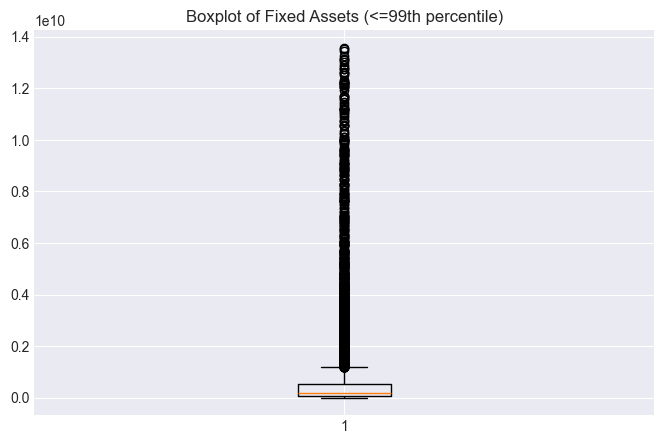

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(train_df_p99["total_fixed_assets"].dropna())

plt.title("Boxplot of Fixed Assets (<=99th percentile)")

plt.show()

In [135]:
print("Before cleaning:")
print(train_df["total_fixed_assets"].describe())

print("\nAfter removing top 1%:")
print(train_df_p99["total_fixed_assets"].describe())

Before cleaning:
count            11,828.00
mean      1,029,206,034.70
std       6,120,958,154.91
min           1,267,167.28
25%          73,198,030.24
50%         190,599,471.63
75%         539,874,121.35
max     254,871,222,410.09
Name: total_fixed_assets, dtype: float64

After removing top 1%:
count           11,709.00
mean       614,105,632.49
std      1,369,273,651.99
min          1,267,167.28
25%         72,465,743.18
50%        187,721,138.27
75%        517,300,938.13
max     13,573,252,683.38
Name: total_fixed_assets, dtype: float64


In [139]:
extreme_fixed = train_df[
    (train_df["fixed_asset_ratio"] > 80) |
    (train_df["fixed_asset_ratio"] < 0.02)
]

print("Extreme fixed asset jumps:", len(extreme_fixed))

bad_companies_fixed = extreme_fixed["company_id"].unique()

print("Companies with abnormal fixed asset jumps:", len(bad_companies_fixed))

Extreme fixed asset jumps: 162
Companies with abnormal fixed asset jumps: 141


In [140]:
train_df = train_df.sort_values(["company_id","fiscal_year"])

train_df["fixed_asset_ratio"] = (
    train_df.groupby("company_id")["total_fixed_assets"]
    .transform(lambda x: x / x.shift(1))
)

ratio_filter = train_df[
    (train_df["fixed_asset_ratio"] > 70) |
    (train_df["fixed_asset_ratio"] < 0.05)
]

In [141]:
rows_ratio_removed = len(ratio_filter)

print("Rows removed by ratio method:", rows_ratio_removed)

Rows removed by ratio method: 436


In [142]:
print(
    "Percentage removed (ratio):",
    rows_ratio_removed / len(train_df) * 100
)

Percentage removed (ratio): 3.68616841393304


In [143]:
p99 = train_df["total_fixed_assets"].quantile(0.99)

percentile_filter = train_df[
    train_df["total_fixed_assets"] > p99
]

In [144]:
rows_percentile_removed = len(percentile_filter)

print("Rows removed by percentile method:", rows_percentile_removed)

Rows removed by percentile method: 119


In [145]:
print(
    "Percentage removed (p99):",
    rows_percentile_removed / len(train_df) * 100
)

Percentage removed (p99): 1.006087250591816


Min total_assets: 2545967.78
Max total_assets: 506126155812.4
Mean total_assets: 2467641266.2027917
Median total_assets: 521237912.25


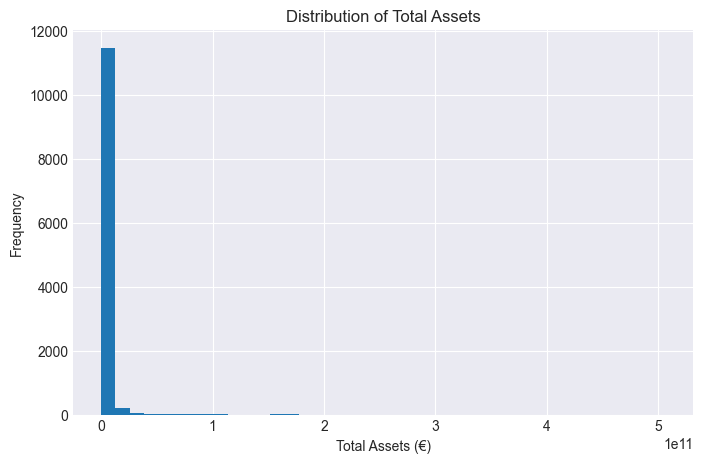

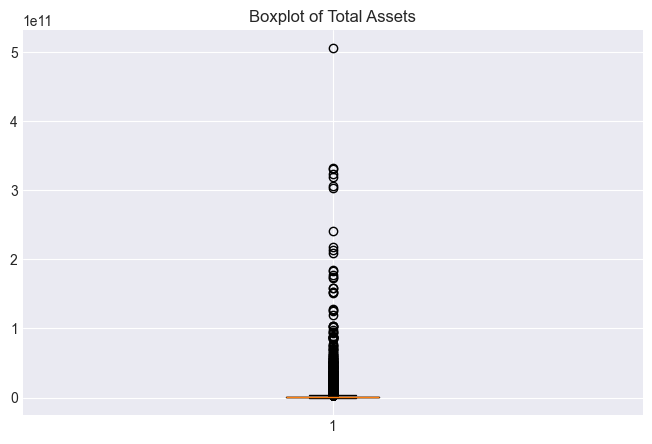

Rows where accounting identity fails: 3020
Percentage inconsistent: 25.5326344267839


In [63]:
print("Min total_assets:", train_df["total_assets"].min())
print("Max total_assets:", train_df["total_assets"].max())
print("Mean total_assets:", train_df["total_assets"].mean())
print("Median total_assets:", train_df["total_assets"].median())
train_df["total_assets"].describe()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(train_df["total_assets"].dropna(), bins=40)

plt.title("Distribution of Total Assets")
plt.xlabel("Total Assets (€)")
plt.ylabel("Frequency")

plt.show()
plt.figure(figsize=(8,5))

plt.boxplot(train_df["total_assets"].dropna())

plt.title("Boxplot of Total Assets")

plt.show()
asset_diff = (
    train_df["total_assets"]
    - (train_df["total_fixed_assets"] + train_df["current_assets"])
)
tolerance = 1e-6

inconsistent_rows = train_df[abs(asset_diff) > tolerance]

print("Rows where accounting identity fails:", len(inconsistent_rows))
print(
    "Percentage inconsistent:",
    len(inconsistent_rows) / len(train_df) * 100
)

In [64]:
train_df[train_df["total_assets"] == 506126155812.4][
    ["company_id", "fiscal_year", "region", "province", "total_assets"]
]

,company_id,fiscal_year,region,province,total_assets
7617,COMP_01931,2020,Liguria,GE,"506,126,155,812.40"


In [65]:
train_df[train_df["province"] == "MO"].sort_values(
    "total_assets",
    ascending=False
)[["company_id", "fiscal_year", "region", "province", "total_assets"]].head(1)

,company_id,fiscal_year,region,province,total_assets
9753,COMP_02475,2021,Emilia-Romagna,MO,"95,248,914,415.74"


In [66]:
asset_diff = train_df["total_assets"] - (
    train_df["total_fixed_assets"] + train_df["current_assets"]
)

print(asset_diff.describe())

count   11,828.00
mean         0.00
std          0.00
min         -0.01
25%          0.00
50%          0.00
75%          0.00
max          0.01
dtype: float64


In [68]:
import pandas as pd

bins = [
    0,
    100_000_000,
    300_000_000,
    1_000_000_000,
    10_000_000_000,
    100_000_000_000,
    300_000_000_000,
    float("inf")
]

labels = [
    "0–100M",
    "100M–300M",
    "300M–1B",
    "1B–10B",
    "10B–100B",
    "100B-300B",
    "300B+"
]

train_df["assets_range"] = pd.cut(
    train_df["total_assets"],
    bins=bins,
    labels=labels
)

distribution = (
    train_df.groupby("assets_range")["company_id"]
    .nunique()
    .sort_index()
)

print(distribution)

assets_range
0–100M        978
100M–300M    1869
300M–1B      2315
1B–10B       2035
10B–100B      324
100B-300B      22
300B+           7
Name: company_id, dtype: int64


In [70]:
for asset_range, count in distribution.items():
    print(f"{asset_range}: {count} unique companies")

0–100M: 978 unique companies
100M–300M: 1869 unique companies
300M–1B: 2315 unique companies
1B–10B: 2035 unique companies
10B–100B: 324 unique companies
100B-300B: 22 unique companies
300B+: 7 unique companies


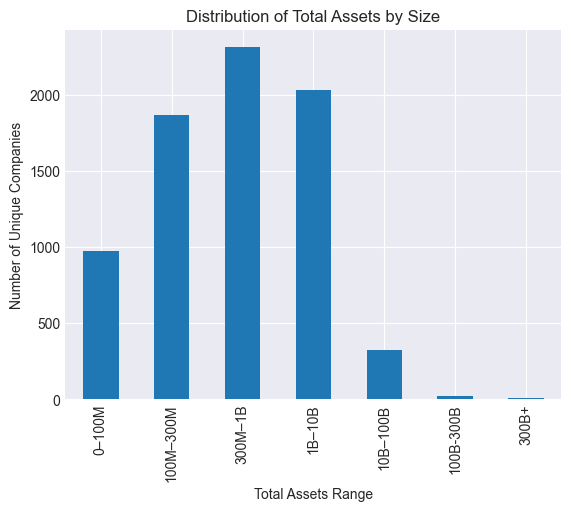

In [69]:
import matplotlib.pyplot as plt

distribution.plot(kind="bar")

plt.title("Distribution of Total Assets by Size")
plt.xlabel("Total Assets Range")
plt.ylabel("Number of Unique Companies")

plt.show()

In [71]:
max_assets_per_company = (
    train_df.groupby("company_id")["total_assets"]
    .max()
)

In [76]:
import pandas as pd

bins = [
    0,
    100_000_000,
    300_000_000,
    1_000_000_000,
    10_000_000_000,
    100_000_000_000,
    300_000_000_000,
    float("inf")
]

labels = [
    "0–100M",
    "100M–300M",
    "300M–1B",
    "1B–10B",
    "10B–100B",
    "100B-300B",
    "300B+"
]

In [77]:
assets_ranges = pd.cut(
    max_assets_per_company,
    bins=bins,
    labels=labels
)
distribution = assets_ranges.value_counts().sort_index()

print(distribution)
for asset_range, count in distribution.items():
    print(f"{asset_range}: {count} unique companies")

total_assets
0–100M          7
100M–300M     133
300M–1B       783
1B–10B       1744
10B–100B      305
100B-300B      20
300B+           7
Name: count, dtype: int64
0–100M: 7 unique companies
100M–300M: 133 unique companies
300M–1B: 783 unique companies
1B–10B: 1744 unique companies
10B–100B: 305 unique companies
100B-300B: 20 unique companies
300B+: 7 unique companies


In [78]:
threshold = 300_000_000_000

big_companies = train_df[
    train_df["total_assets"] > threshold
]["company_id"].unique()

print("Unique companies above threshold:", len(big_companies))
print(big_companies)

Unique companies above threshold: 7
<StringArray>
['COMP_00806', 'COMP_01003', 'COMP_01769', 'COMP_01896', 'COMP_01931',
 'COMP_02542', 'COMP_02677']
Length: 7, dtype: str


In [79]:
print("Companies with total_assets > 3T:")

for comp in big_companies[:7]:
    print(comp)

Companies with total_assets > 3T:
COMP_00806
COMP_01003
COMP_01769
COMP_01896
COMP_01931
COMP_02542
COMP_02677


In [80]:
big_companies_df = train_df[
    train_df["company_id"].isin(big_companies)
]

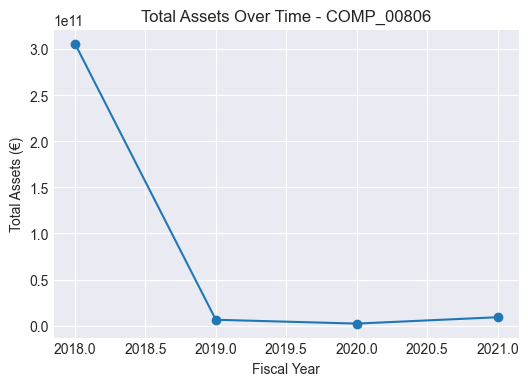

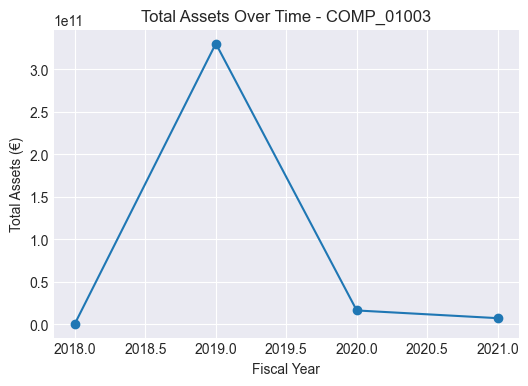

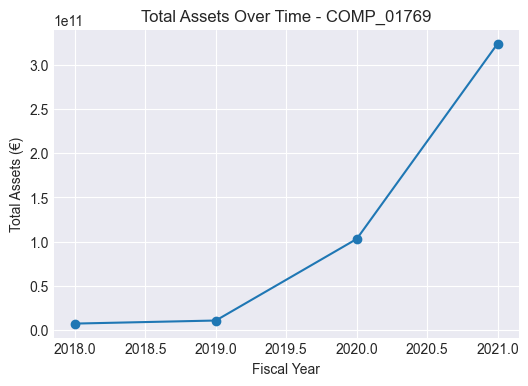

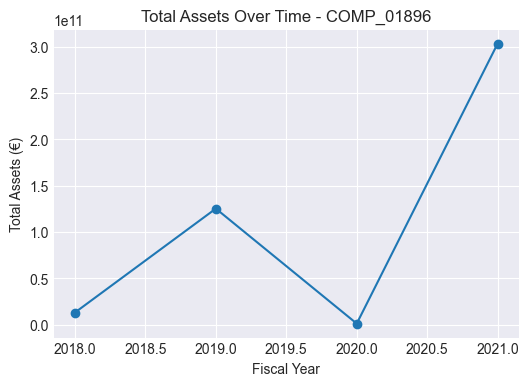

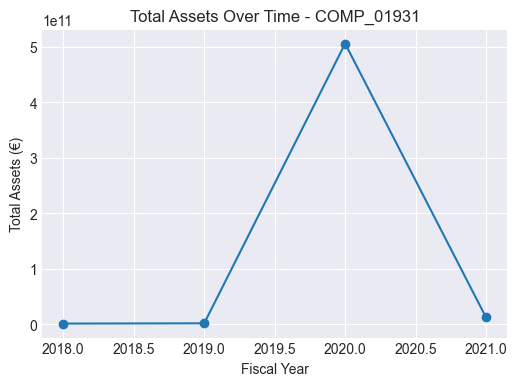

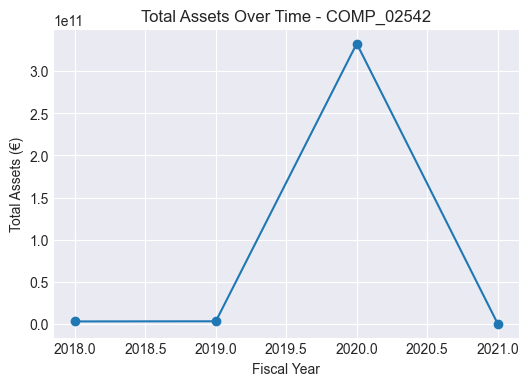

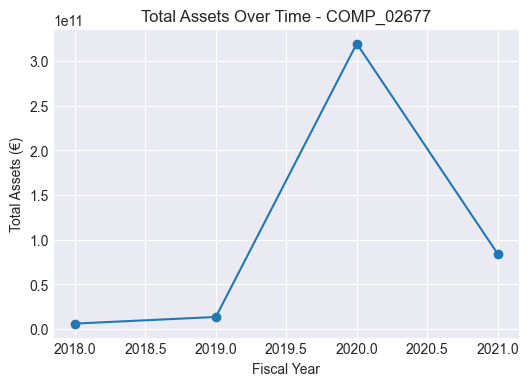

In [82]:
import matplotlib.pyplot as plt

threshold = 300_000_000_000

# aziende con asset sopra la soglia
big_companies = train_df[
    train_df["total_assets"] > threshold
]["company_id"].unique()

# grafico per ciascuna azienda
for comp in big_companies:
    
    company_data = train_df[
        train_df["company_id"] == comp
    ].sort_values("fiscal_year")
    
    plt.figure(figsize=(6,4))
    
    plt.plot(
        company_data["fiscal_year"],
        company_data["total_assets"],
        marker="o"
    )
    
    plt.title(f"Total Assets Over Time - {comp}")
    plt.xlabel("Fiscal Year")
    plt.ylabel("Total Assets (€)")
    
    plt.grid(True)
    
    plt.show()

short term debt

In [84]:
print("Min short_term_debt:", train_df["short_term_debt"].min())
print("Max short_term_debt:", train_df["short_term_debt"].max())
print("Mean short_term_debt:", train_df["short_term_debt"].mean())
print("Median short_term_debt:", train_df["short_term_debt"].median())
train_df["short_term_debt"].describe()

Min short_term_debt: 898546.06
Max short_term_debt: 169968538153.77
Mean short_term_debt: 853465556.0625168
Median short_term_debt: 174480152.675


count            11,828.00
mean        853,465,556.06
std       4,360,359,782.65
min             898,546.06
25%          69,256,174.04
50%         174,480,152.68
75%         477,729,823.86
max     169,968,538,153.77
Name: short_term_debt, dtype: float64

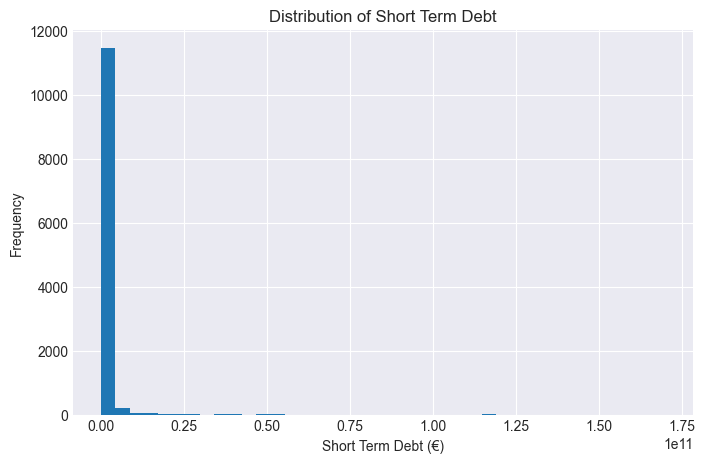

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(train_df["short_term_debt"].dropna(), bins=40)

plt.title("Distribution of Short Term Debt")
plt.xlabel("Short Term Debt (€)")
plt.ylabel("Frequency")

plt.show()

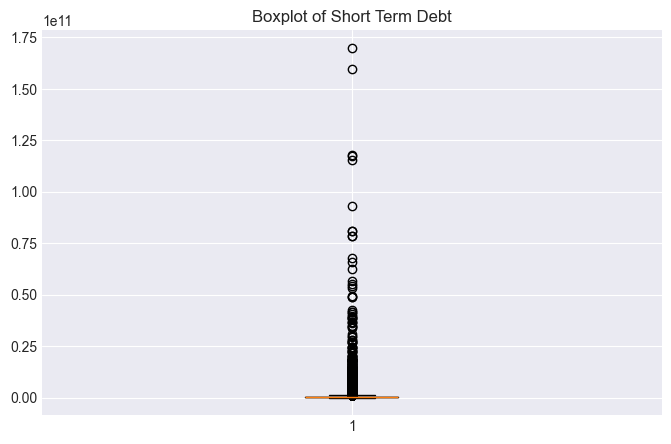

In [86]:
plt.figure(figsize=(8,5))

plt.boxplot(train_df["short_term_debt"].dropna())

plt.title("Boxplot of Short Term Debt")

plt.show()

In [87]:
bins = [
    0,
    1_000_000,
    10_000_000,
    100_000_000,
    1_000_000_000,
    float("inf")
]

labels = [
    "0–1M",
    "1M–10M",
    "10M–100M",
    "100M–1B",
    "1B+"
]

train_df["short_debt_range"] = pd.cut(
    train_df["short_term_debt"],
    bins=bins,
    labels=labels
)

distribution = train_df.groupby("short_debt_range")["company_id"].nunique()

print(distribution)

short_debt_range
0–1M           1
1M–10M       163
10M–100M    2152
100M–1B     2760
1B+          972
Name: company_id, dtype: int64


long term debt

In [89]:
print("Min long_term_debt:", train_df["long_term_debt"].min())
print("Max long_term_debt:", train_df["long_term_debt"].max())
print("Mean long_term_debt:", train_df["long_term_debt"].mean())
print("Median long_term_debt:", train_df["long_term_debt"].median())
train_df["long_term_debt"].describe()

Min long_term_debt: 941244.87
Max long_term_debt: 140543085703.5
Mean long_term_debt: 697861652.8886058
Median long_term_debt: 146258470.09


count            11,828.00
mean        697,861,652.89
std       3,493,369,047.57
min             941,244.87
25%          56,663,618.11
50%         146,258,470.09
75%         396,007,036.00
max     140,543,085,703.50
Name: long_term_debt, dtype: float64

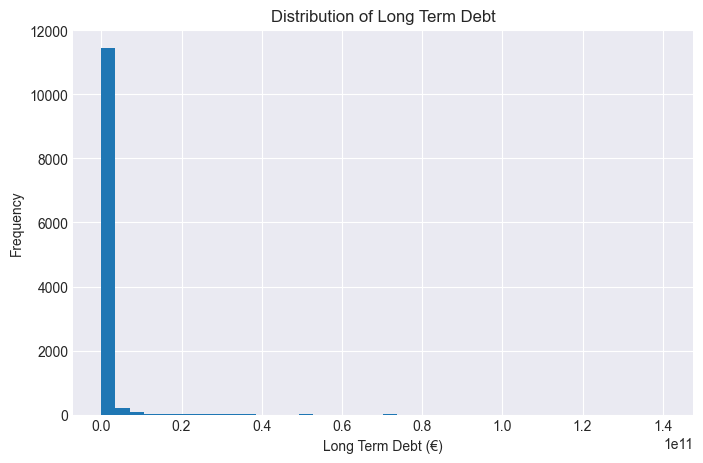

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(train_df["long_term_debt"].dropna(), bins=40)

plt.title("Distribution of Long Term Debt")
plt.xlabel("Long Term Debt (€)")
plt.ylabel("Frequency")

plt.show()

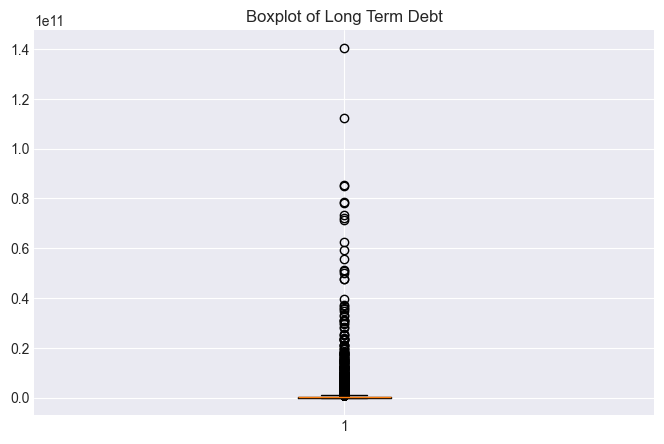

In [91]:
plt.figure(figsize=(8,5))

plt.boxplot(train_df["long_term_debt"].dropna())

plt.title("Boxplot of Long Term Debt")

plt.show()

total debt

In [92]:
debt_diff = train_df["total_debt"] - (
    train_df["short_term_debt"] + train_df["long_term_debt"]
)

In [93]:
tolerance = 1e-6

inconsistent_debt = train_df[abs(debt_diff) > tolerance]

print("Rows where debt identity fails:", len(inconsistent_debt))
print("Percentage inconsistent:",
      len(inconsistent_debt) / len(train_df) * 100)

Rows where debt identity fails: 3092
Percentage inconsistent: 26.141359485965506


In [94]:
tolerance = 1e-6

inconsistent_debt = train_df[abs(debt_diff) > tolerance]

print("Rows where debt identity fails:", len(inconsistent_debt))
print("Percentage inconsistent:",
      len(inconsistent_debt) / len(train_df) * 100)

Rows where debt identity fails: 3092
Percentage inconsistent: 26.141359485965506


In [95]:
inconsistent_debt[
    [
        "company_id",
        "fiscal_year",
        "short_term_debt",
        "long_term_debt",
        "total_debt"
    ]
].head(10)

,company_id,fiscal_year,short_term_debt,long_term_debt,total_debt
1,COMP_00000,2019,"71,353,454.66","52,598,482.25","123,951,936.92"
3,COMP_00000,2021,"152,767,378.78","107,016,309.07","259,783,687.84"
4,COMP_00001,2018,"75,824,818.70","74,555,843.95","150,380,662.66"
10,COMP_00002,2020,"309,658,592.15","249,900,619.37","559,559,211.51"
11,COMP_00002,2021,"23,564,820.19","21,505,219.99","45,070,040.19"
17,COMP_00004,2020,"254,076,570.90","151,815,397.94","405,891,968.85"
19,COMP_00005,2018,"57,768,929.61","56,074,022.10","113,842,951.72"
23,COMP_00006,2018,"184,645,491.37","176,359,875.06","361,005,366.42"
27,COMP_00007,2018,"19,470,865.24","10,440,316.92","29,911,182.17"
28,COMP_00007,2019,"540,742,314.69","376,973,224.63","917,715,539.31"


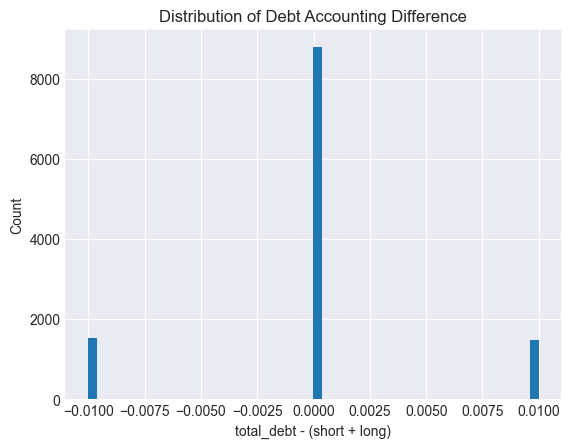

In [96]:
import matplotlib.pyplot as plt

plt.hist(debt_diff.dropna(), bins=50)

plt.title("Distribution of Debt Accounting Difference")
plt.xlabel("total_debt - (short + long)")
plt.ylabel("Count")

plt.show()

In [97]:
print(debt_diff.describe())

count   11,828.00
mean        -0.00
std          0.01
min         -0.01
25%          0.00
50%          0.00
75%          0.00
max          0.01
dtype: float64


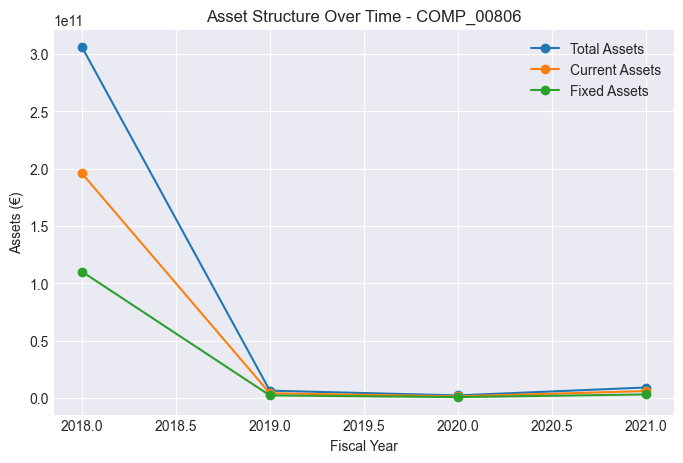

In [98]:
import matplotlib.pyplot as plt

threshold = 300_000_000_000

# trova aziende sopra la soglia
big_company = train_df[
    train_df["total_assets"] > threshold
]["company_id"].iloc[0]

# dati dell'azienda
company_data = train_df[
    train_df["company_id"] == big_company
].sort_values("fiscal_year")

# grafico
plt.figure(figsize=(8,5))

plt.plot(
    company_data["fiscal_year"],
    company_data["total_assets"],
    marker="o",
    label="Total Assets"
)

plt.plot(
    company_data["fiscal_year"],
    company_data["current_assets"],
    marker="o",
    label="Current Assets"
)

plt.plot(
    company_data["fiscal_year"],
    company_data["total_fixed_assets"],
    marker="o",
    label="Fixed Assets"
)

plt.title(f"Asset Structure Over Time - {big_company}")
plt.xlabel("Fiscal Year")
plt.ylabel("Assets (€)")

plt.legend()
plt.grid(True)

plt.show()

Income Statement Variables

Financial Ratios (Pre-calculated)

Leverage Ratios

Liquidity Ratios

In [ ]:
EDA

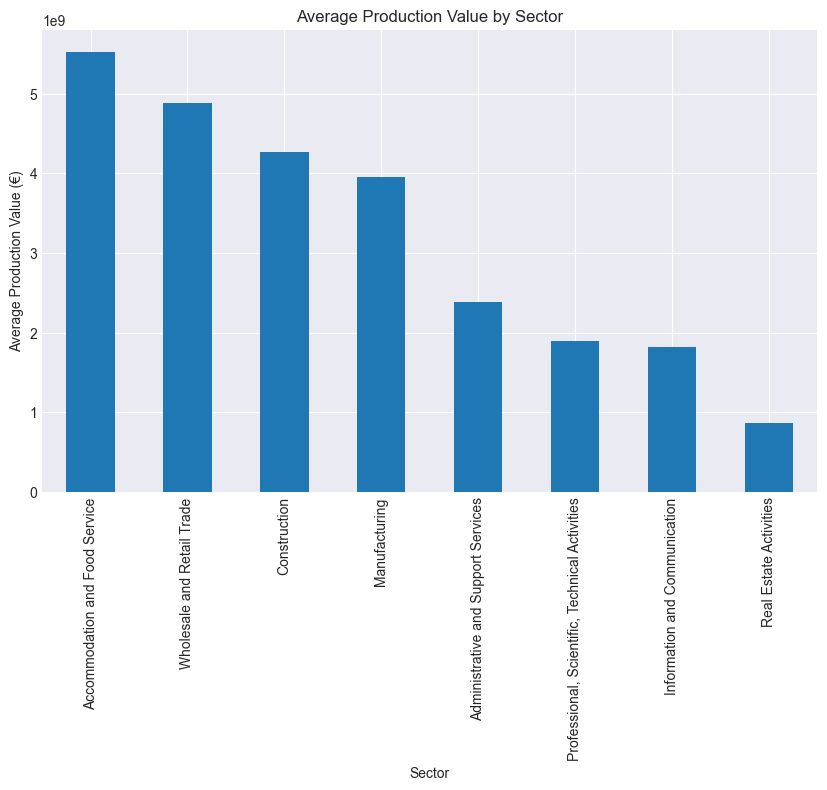

In [146]:
import matplotlib.pyplot as plt

sector_pv = (
    train_df.groupby("sector_category")["production_value"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sector_pv.plot(kind="bar")

plt.title("Average Production Value by Sector")
plt.ylabel("Average Production Value (€)")
plt.xlabel("Sector")

plt.show()

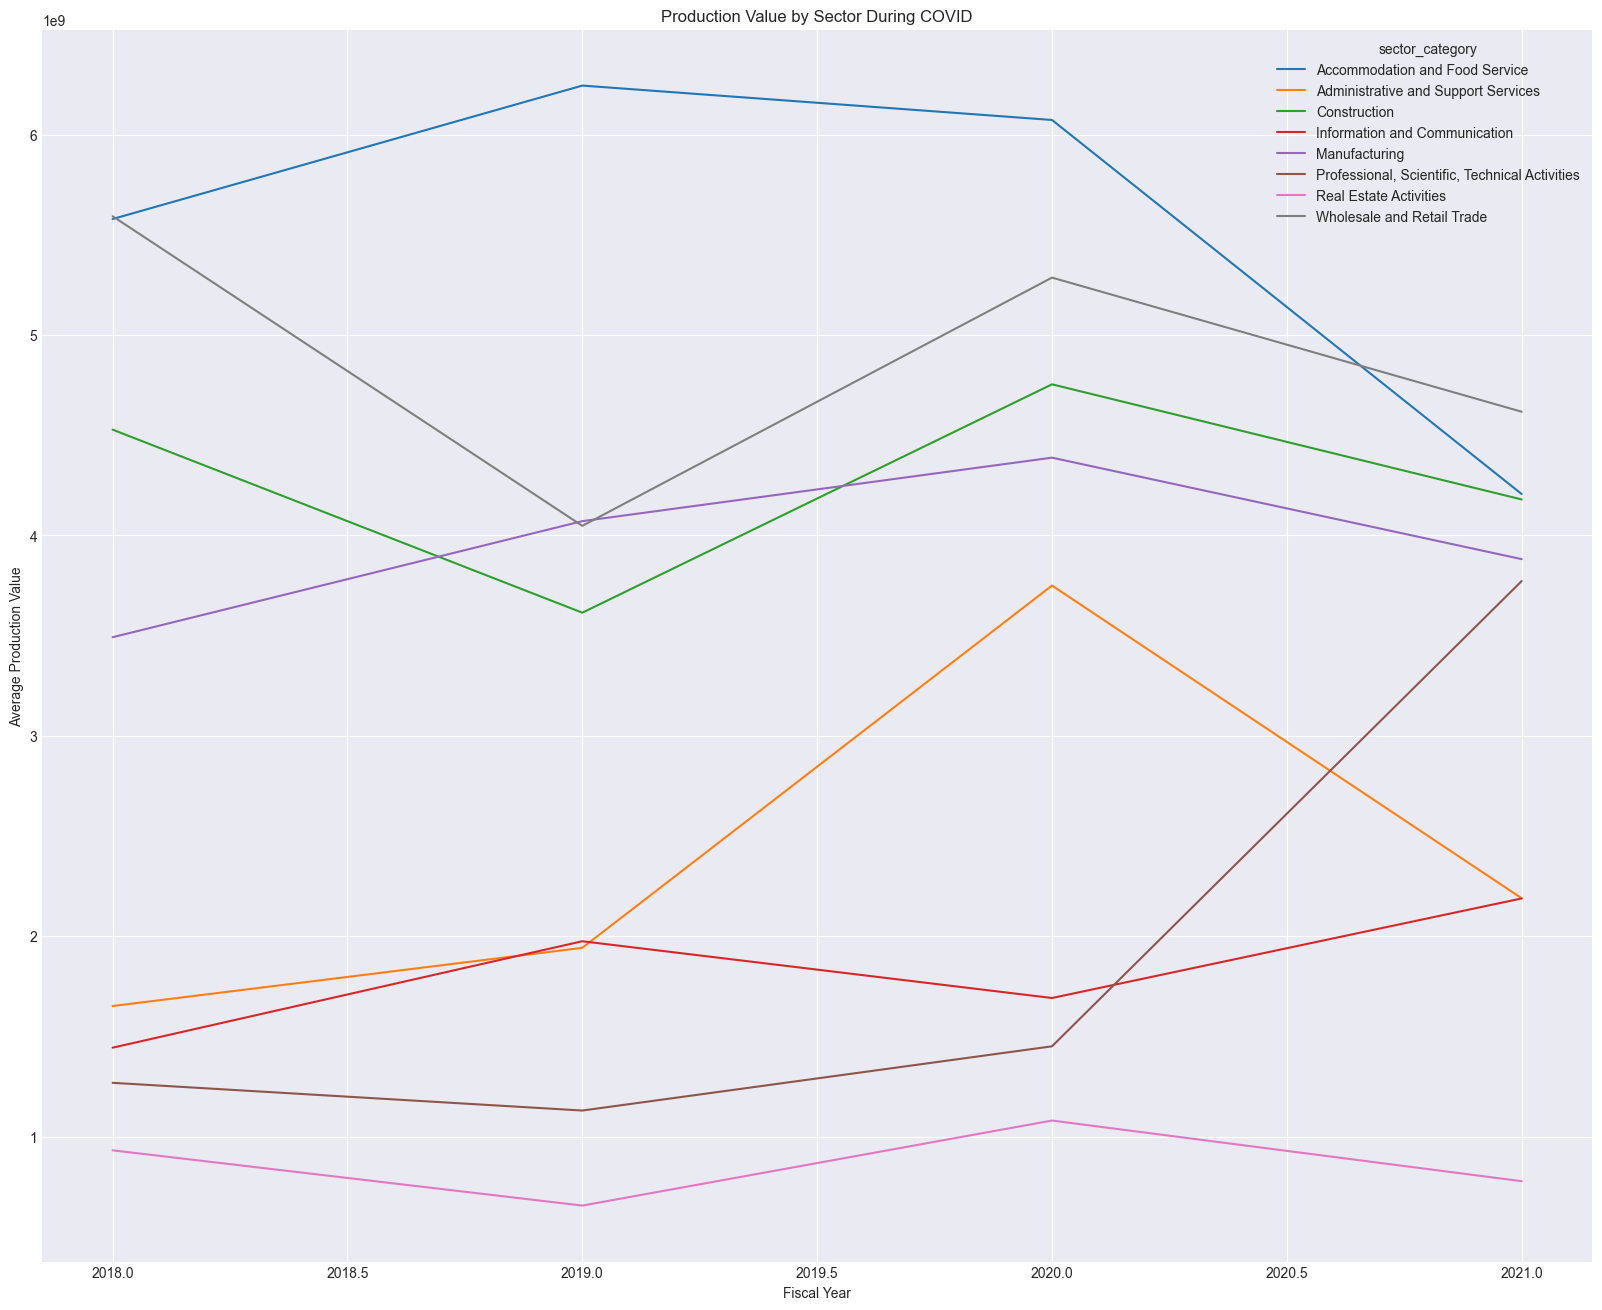

In [161]:
sector_year_pv = (
    train_df.groupby(["sector_category","fiscal_year"])["production_value"]
    .mean()
    .unstack()
)

sector_year_pv.T.plot(figsize=(20,16))

plt.title("Production Value by Sector During COVID")
plt.ylabel("Average Production Value")
plt.xlabel("Fiscal Year")

plt.show()

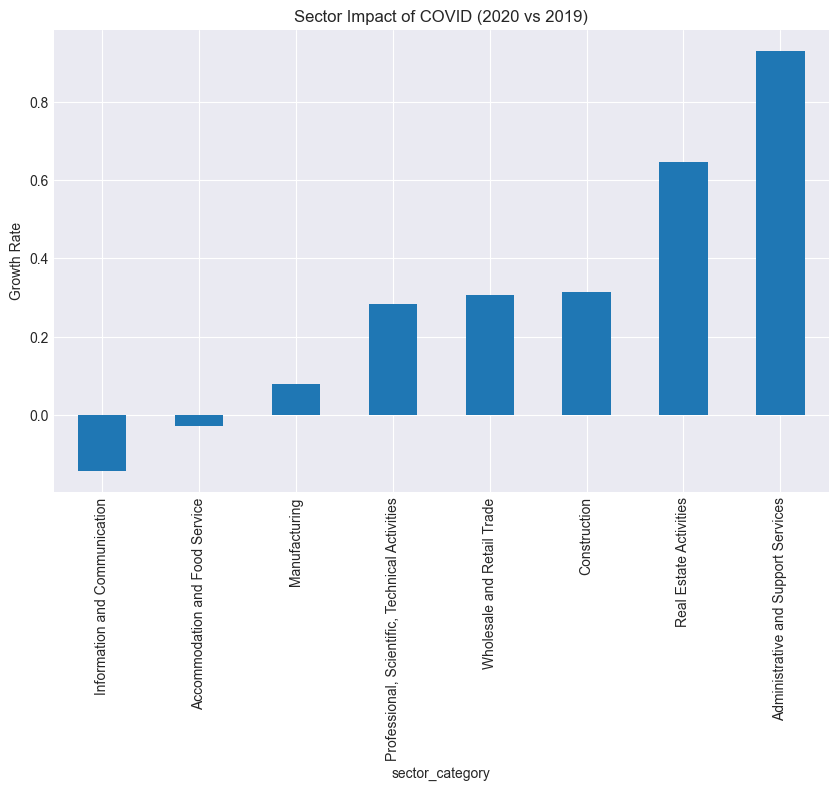

In [148]:
pv_2019 = train_df[train_df["fiscal_year"]==2019].groupby("sector_category")["production_value"].mean()
pv_2020 = train_df[train_df["fiscal_year"]==2020].groupby("sector_category")["production_value"].mean()

covid_drop = (pv_2020 - pv_2019) / pv_2019

covid_drop.sort_values().plot(kind="bar", figsize=(10,6))

plt.title("Sector Impact of COVID (2020 vs 2019)")
plt.ylabel("Growth Rate")

plt.show()

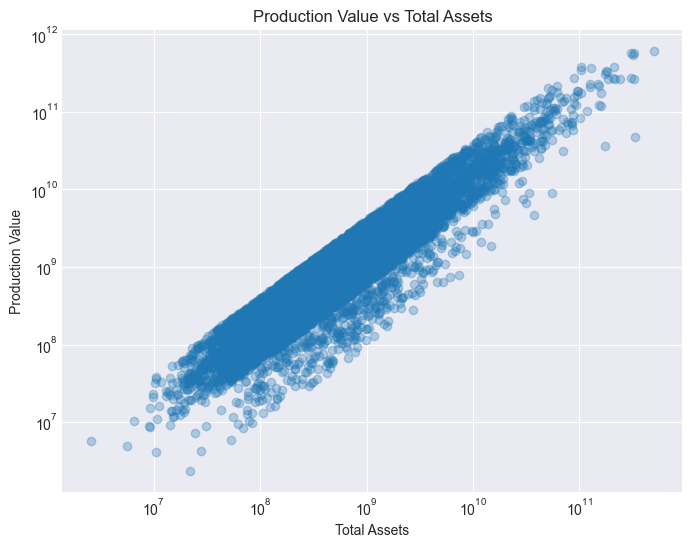

In [149]:
plt.figure(figsize=(8,6))

plt.scatter(
    train_df["total_assets"],
    train_df["production_value"],
    alpha=0.3
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Total Assets")
plt.ylabel("Production Value")

plt.title("Production Value vs Total Assets")

plt.show()

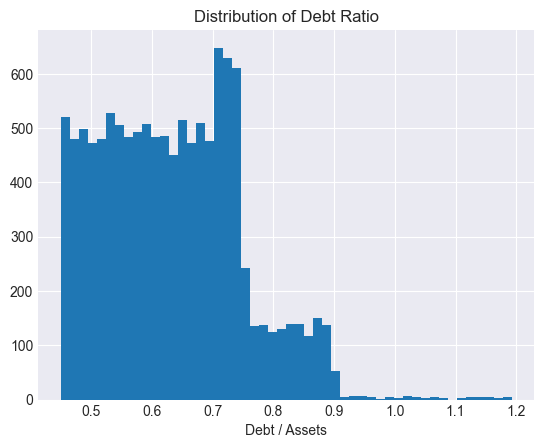

In [150]:
train_df["debt_ratio"] = train_df["total_debt"] / train_df["total_assets"]

plt.hist(train_df["debt_ratio"].dropna(), bins=50)

plt.title("Distribution of Debt Ratio")
plt.xlabel("Debt / Assets")

plt.show()

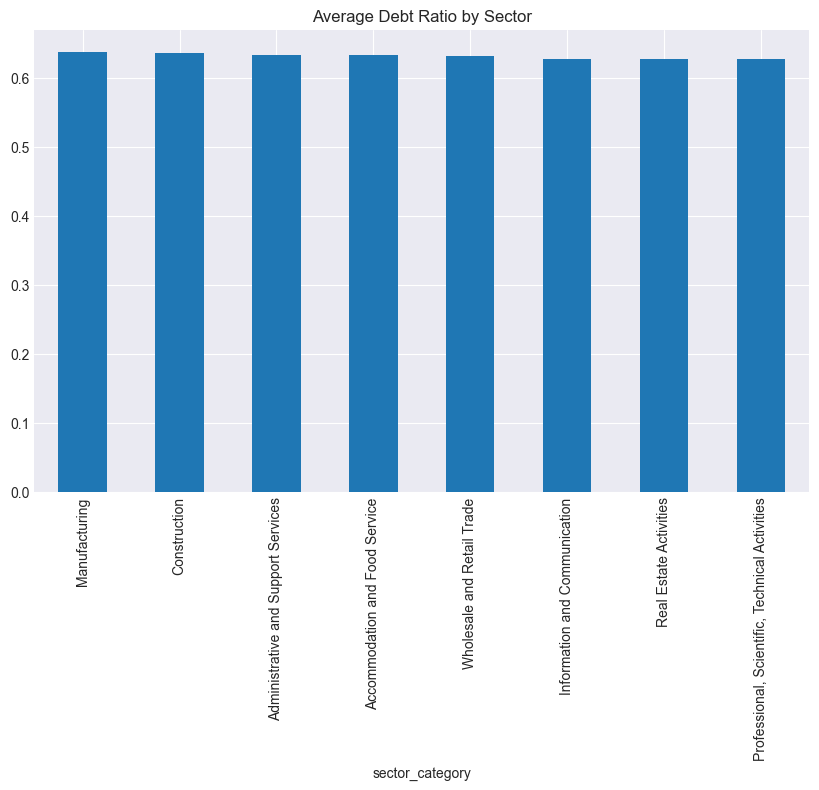

In [151]:
sector_debt = (
    train_df.groupby("sector_category")["debt_ratio"]
    .mean()
    .sort_values(ascending=False)
)

sector_debt.plot(kind="bar", figsize=(10,6))

plt.title("Average Debt Ratio by Sector")

plt.show()

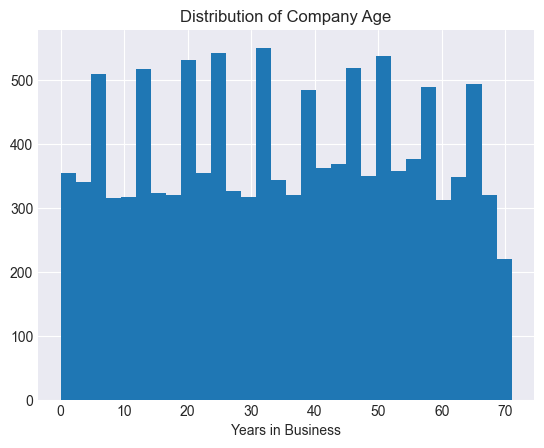

In [152]:
plt.hist(train_df["years_in_business"], bins=30)

plt.title("Distribution of Company Age")
plt.xlabel("Years in Business")

plt.show()

<Figure size 1200x600 with 0 Axes>

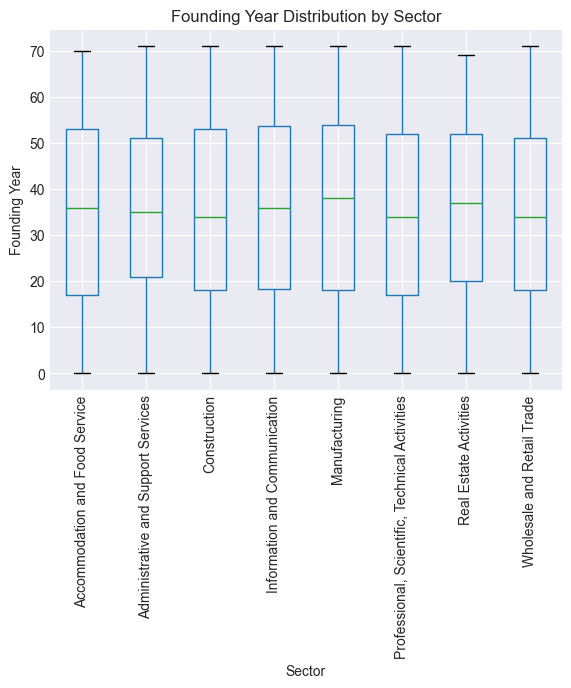

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

train_df.boxplot(
    column="years_in_business",
    by="sector_category",
    rot=90
)

plt.title("Founding Year Distribution by Sector")
plt.suptitle("")
plt.xlabel("Sector")
plt.ylabel("Founding Year")

plt.show()

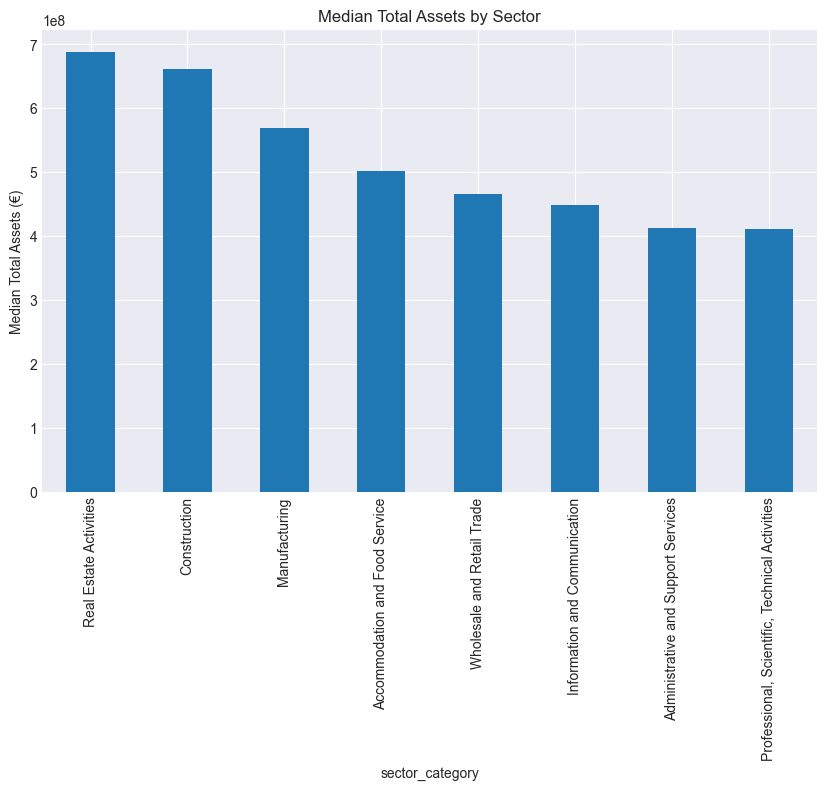

In [157]:
sector_assets = (
    train_df.groupby("sector_category")["total_assets"]
    .median()
    .sort_values(ascending=False)
)

sector_assets.plot(kind="bar", figsize=(10,6))

plt.title("Median Total Assets by Sector")
plt.ylabel("Median Total Assets (€)")

plt.show()

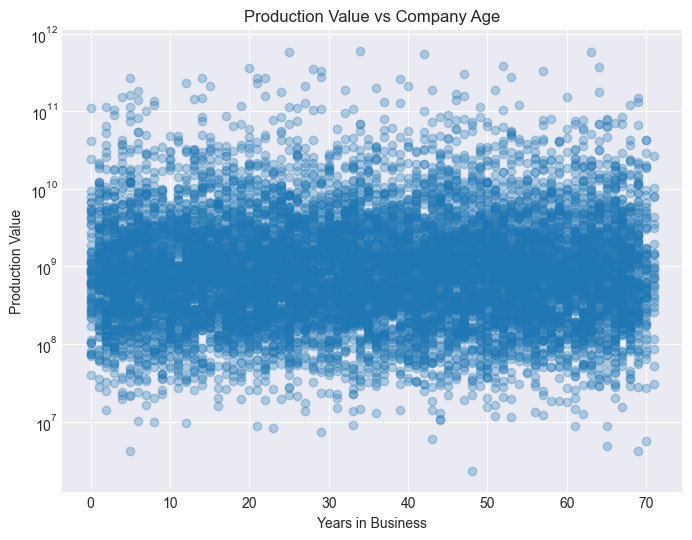

In [158]:
plt.figure(figsize=(8,6))

plt.scatter(
    train_df["years_in_business"],
    train_df["production_value"],
    alpha=0.3
)

plt.yscale("log")

plt.xlabel("Years in Business")
plt.ylabel("Production Value")

plt.title("Production Value vs Company Age")

plt.show()

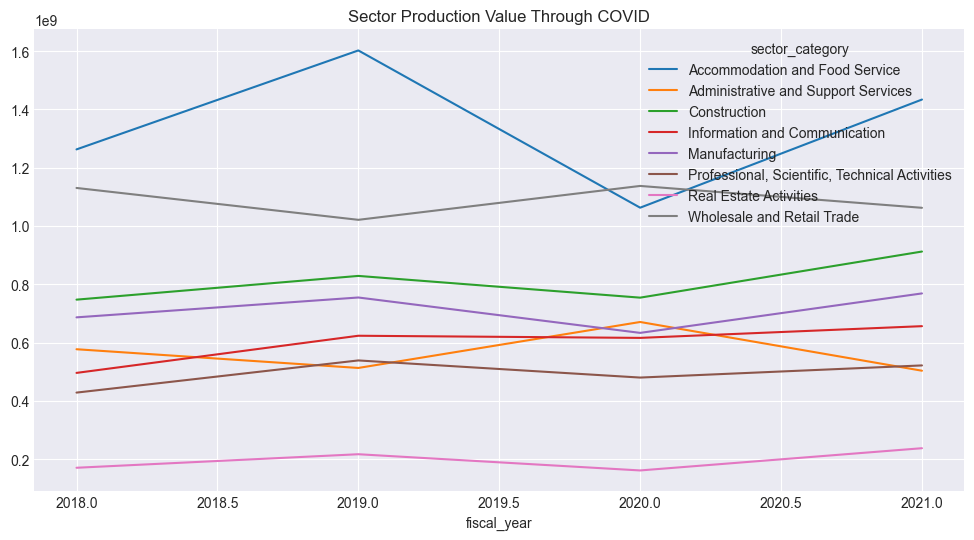

In [159]:
pv_sector_year = (
    train_df.groupby(["sector_category","fiscal_year"])["production_value"]
    .median()
    .unstack()
)

pv_sector_year.T.plot(figsize=(12,6))

plt.title("Sector Production Value Through COVID")

plt.show()

ARIMA funziona quando hai:

una serie temporale lunga

Questo tipo di dati si chiama:

panel data
firm-year dataset

La soluzione tipica è:

tabular machine learning

non time series classica.

Quelli usati anche nella ricerca economica:

Gradient Boosting
LightGBM
XGBoost
CatBoost

Sono i migliori per dati finanziari.

In [ ]:
ARIMAX ha senso se hai tipo:

GDP annuale 1960-2024

oppure

inflazione mensile

dove hai molti punti temporali.

Pipeline tipica:

feature engineering
↓
lag variables
↓
financial ratios
↓
LightGBM / XGBoost

Questo è lo standard per corporate finance ML.

Non ignoriamo il tempo, ma lo usiamo come feature:

growth rates
lag variables
year dummy
covid dummy